# Logistic Regression Part 1: The Sigmoid and the Forward Pass

## Goal

Before training logistic regression, we first want to understand the model's **forward pass**.

In linear regression, the model outputs a real number:

$$
\hat{y} = w^\top x + b
$$

In logistic regression, the model first computes a linear score called the **logit**:

$$
a = w^\top x + b
$$

Then it passes that logit through the **sigmoid function** to convert it into a probability:

$$
\mu = \sigma(a) = \frac{1}{1 + e^{-a}}
$$

The output `mu` is interpreted as:

$$
\mu = p(y = 1 \mid x)
$$

So logistic regression is still linear in the parameters, but its final output is a probability between `0` and `1`.

---

## The Logit

The logit is:

$$
a = w^\top x + b
$$

where:

- `x` is the input feature vector
- `w` is the weight vector
- `b` is the bias/intercept
- `a` is the logit, also called the pre-activation or log-odds

For a 2D input:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

and:

$$
w =
\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}
$$

the logit is:

$$
a = w_1x_1 + w_2x_2 + b
$$

---

## The Sigmoid Function

The sigmoid function is:

$$
\sigma(a) = \frac{1}{1 + e^{-a}}
$$

It maps any real number into the interval between `0` and `1`.

So:

```python
large positive a  -> sigmoid(a) close to 1
a = 0             -> sigmoid(a) = 0.5
large negative a  -> sigmoid(a) close to 0
```

This makes it useful for binary classification.

---

## Decision Rule

The model predicts class `1` when the probability is greater than `0.5`.

Since:

$$
\sigma(0) = 0.5
$$

the decision rule can be written as:

$$
\hat{y} = \mathbf{1}(a > 0)
$$

This means:

```python
if a > 0:
    predict class 1
else:
    predict class 0
```

Equivalently:

```python
if sigmoid(a) > 0.5:
    predict class 1
else:
    predict class 0
```

---

## Decision Boundary

The decision boundary occurs where the model is exactly uncertain:

$$
\mu = 0.5
$$

This happens when:

$$
a = 0
$$

So the decision boundary is:

$$
w^\top x + b = 0
$$

For two features, this becomes:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Solving for `x2`:

$$
x_2 = -\frac{w_1x_1 + b}{w_2}
$$

This is the line that separates the two predicted classes.

---

## Role of the Weight Vector

The weight vector `w` controls the decision boundary.

The **direction** of `w` determines the orientation of the boundary.

The **magnitude** of `w`, written as:

$$
\|w\| = \sqrt{w_1^2 + w_2^2}
$$

controls how steep the sigmoid is.

If we multiply `w` by a larger number while keeping its direction fixed, the decision boundary stays in the same place, but the probabilities become more confident.

For example:

```python
w_scaled = 5 * w
```

This makes the sigmoid transition more sharply from `0` to `1`.

So:

```text
small ||w||  -> smoother probability transition
large ||w||  -> sharper probability transition
```

This matters later because when the sigmoid saturates near `0` or `1`, the gradient can become very small.

---

## Main Idea

Logistic regression follows this forward pass:

```text
input x
   ↓
linear logit: a = w^T x + b
   ↓
sigmoid: mu = sigmoid(a)
   ↓
probability: p(y = 1 | x)
   ↓
prediction: y_hat = 1(a > 0)
```

The model is still based on a linear function, but the sigmoid turns that linear score into a probability.

The boundary is linear, but the output is probabilistic.

In [3093]:
import numpy as np
import matplotlib.pyplot as plt 

## Implementing and Plotting the Sigmoid Function

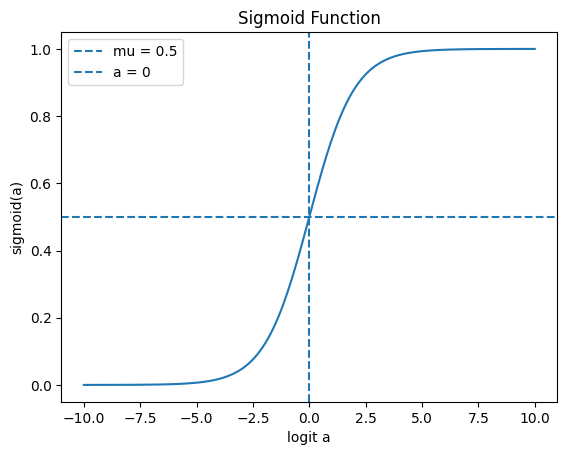

In [3094]:
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

# plot sigmoid from -10 to 10
a_values    =   np.linspace(-10, 10, 200)
mu_values   =   sigmoid(a_values)

plt.plot(a_values, mu_values)
plt.axhline(0.5, linestyle="--", label="mu = 0.5")
plt.axvline(0, linestyle="--", label="a = 0")
plt.xlabel("logit a")
plt.ylabel("sigmoid(a)")
plt.title("Sigmoid Function")
plt.legend()
plt.legend()
plt.show()

**Important thing to note**: Sigmoid flattens nears 0 and 1. This is called **saturation**. 

## Generate 2D Linearly Separable Data 


In [3095]:
np.random.seed(0)

n_per_class = 100

# class 0 centered around (-2, -2)
X0 = np.random.randn(n_per_class, 2) + np.array([-2, -2])

# class 1 centered around (2, 2)
X1 = np.random.randn(n_per_class, 2) + np.array([2, 2])

# combine data
X = np.vstack([X0, X1])

# labels
y = np.array([0] * n_per_class + [1] * n_per_class)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 2)
y shape: (200,)


### Plotting the data

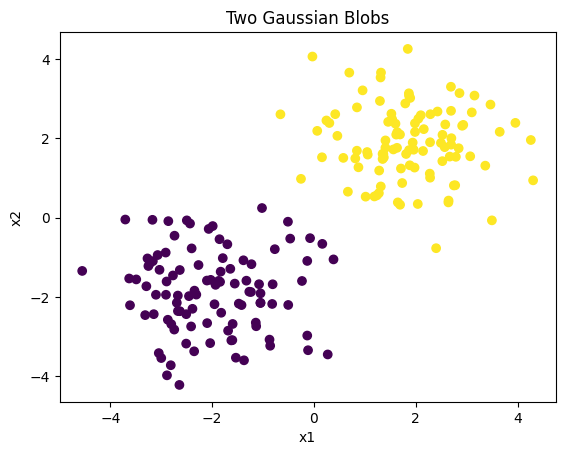

In [3096]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Gaussian Blobs")
plt.show()

### Pick w and b by Hand

Since class 0 is near $(-2, 2)$ and class 1 is near $(2, 2)$, a reasonable boundary is something like:

$$x_1 + x_2 = 0$$

So we choose:

```python
w = np.array([1.0, 1.0])
b = 0.0
```

And compute the logits:

In [3097]:
w = np.array([1.0, 1.0])
b = 0.0

logits = X @ w + b

mu = sigmoid(logits)

y_pred = (logits > 0).astype(int)

# Check accuracy 
accuracy = np.mean(y_pred == y)

print("Accuracy:", accuracy)
print("First 10 logits:", logits[:10])
print("First 10 probabilities:", mu[:10])
print("First 10 predictions:", y_pred[:10])

Accuracy: 1.0
First 10 logits: [-1.83579045 -0.78036882 -3.10971989 -3.20126879 -3.69262035 -2.40168292
 -3.11728726 -3.22246244 -2.71107919 -4.54102804]
First 10 probabilities: [0.13754991 0.3142404  0.04270809 0.039118   0.02430139 0.08304446
 0.04239978 0.03832912 0.06232276 0.01054995]
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


### Plotting the Data, Decision Boundary, and Probability Contours

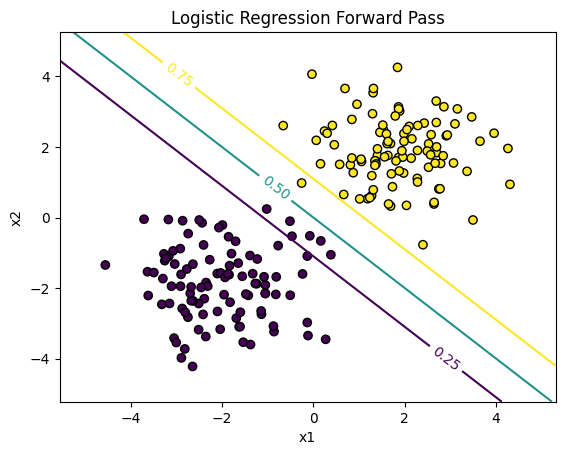

In [3098]:
# create grid for plotting
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

# flatten grid points into shape (num_points, 2)
grid = np.c_[xx1.ravel(), xx2.ravel()]

# compute logits and probabilities on grid
grid_logits = grid @ w + b
grid_mu = sigmoid(grid_logits)

# reshape back to grid shape
grid_mu = grid_mu.reshape(xx1.shape)

# plot data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", label="Data")

# probability contours
contours = plt.contour(
    xx1,
    xx2,
    grid_mu,
    levels=[0.25, 0.5, 0.75]
)
plt.clabel(contours)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Forward Pass")
plt.show()

## Scale w by 5 and Compare 

Keeping the same direction, but making the magnitude bigger: 

```python
w_scaled = 5 * w
b_scaled = b
```

In [3099]:
w_scaled = 5 * w
b_scaled = b

# computing the probabilities again
grid_logits_scaled = grid @ w_scaled + b_scaled
grid_mu_scaled = sigmoid(grid_logits_scaled)
grid_mu_scaled = grid_mu_scaled.reshape(xx1.shape)

### Plotting scaled version

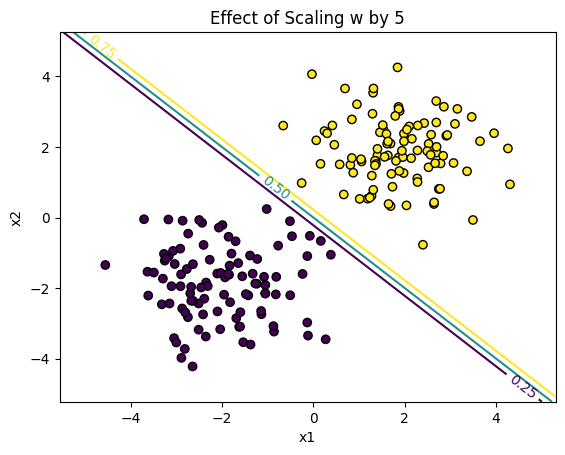

In [3100]:
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", label="Data")

contours = plt.contour(
    xx1,
    xx2,
    grid_mu_scaled,
    levels=[0.25, 0.5, 0.75]
)

plt.clabel(contours)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Effect of Scaling w by 5")
plt.show()

**Note**: the 0.5 boundary stays in the same place, but the 0.25 and 0.75 boundary contours move closer together. 

# Logistic Regression Part 2: Cross-Entropy Loss and Why There Is No Closed Form

## Goal

In linear regression, we used squared error and were able to solve for the weights directly using the normal equation:

$$
X^\top Xw = X^\top y
$$

which gave the closed-form solution:

$$
w = (X^\top X)^{-1}X^\top y
$$

For logistic regression, we cannot do this.

The reason is that logistic regression has a **nonlinear sigmoid function** inside the model.

Instead of predicting a real-valued output directly, logistic regression predicts a probability:

$$
\mu_n = \sigma(a_n)
$$

where:

$$
a_n = w^\top x_n
$$

and:

$$
\sigma(a_n) = \frac{1}{1 + e^{-a_n}}
$$

So the prediction is:

$$
\mu_n = p(y_n = 1 \mid x_n)
$$

---

## Why We Need a Different Loss

In linear regression, the output is continuous, so squared error makes sense:

$$
(y_n - \hat{y}_n)^2
$$

But in logistic regression, the output is a probability between `0` and `1`.

The label is binary:

$$
y_n \in \{0, 1\}
$$

So we want the model to assign high probability to the correct class.

If the true label is `1`, we want:

$$
\mu_n \approx 1
$$

If the true label is `0`, we want:

$$
\mu_n \approx 0
$$

This leads to the **negative log-likelihood**, also called **binary cross-entropy loss**.

---

## Binary Cross-Entropy / Negative Log-Likelihood

The logistic regression loss is:

$$
NLL(w) =
-\frac{1}{N}
\sum_{n=1}^{N}
\left[
y_n \log(\mu_n)
+
(1-y_n)\log(1-\mu_n)
\right]
$$

where:

$$
\mu_n = \sigma(w^\top x_n)
$$

This loss comes from maximum likelihood estimation for binary classification.

---

## Interpreting the Loss

For one data point, the loss is:

$$
-\left[
y\log(\mu)
+
(1-y)\log(1-\mu)
\right]
$$

If the true label is `y = 1`, then the loss becomes:

$$
-\log(\mu)
$$

So if the model predicts:

```python
mu = 0.99
```

then the loss is small because the model is confident and correct.

But if the model predicts:

```python
mu = 0.01
```

then the loss is very large because the model is confident and wrong.

---

If the true label is `y = 0`, then the loss becomes:

$$
-\log(1-\mu)
$$

So if the model predicts:

```python
mu = 0.01
```

then the loss is small.

But if the model predicts:

```python
mu = 0.99
```

then the loss is very large.

---

## Why Add Epsilon Inside the Logs?

In code, we should avoid computing:

```python
np.log(0)
```

because this is undefined and gives negative infinity.

So we add a tiny value `epsilon`:

```python
epsilon = 1e-15
```

Then we compute:

```python
np.log(mu + epsilon)
np.log(1 - mu + epsilon)
```

This makes the implementation numerically safer.

---

## Implementing NLL in NumPy

```python
def binary_cross_entropy(y, mu):
    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss
```

For logistic regression:

```python
def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def logistic_nll(X, y, w):
    logits = X @ w
    mu = sigmoid(logits)

    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss
```

---

## Loss Shape for One Point

If the true label is:

```python
y = 1
```

then the loss is:

$$
-\log(\mu)
$$

This means:

```python
mu close to 1  -> small loss
mu close to 0  -> very large loss
```

If the true label is:

```python
y = 0
```

then the loss is:

$$
-\log(1-\mu)
$$

This means:

```python
mu close to 0  -> small loss
mu close to 1  -> very large loss
```

Cross-entropy strongly punishes confident wrong predictions.

---

## Why There Is No Closed-Form Solution

For linear regression, the RSS objective was:

$$
RSS(w) = \frac{1}{2}\|Xw - y\|_2^2
$$

The gradient was:

$$
\nabla_w RSS(w) = X^\top Xw - X^\top y
$$

Setting this equal to zero gave:

$$
X^\top Xw = X^\top y
$$

This worked because the gradient was **linear in** `w`.

---

For logistic regression, the gradient of the NLL is:

$$
\nabla_w NLL(w)
=
\frac{1}{N}
\sum_{n=1}^{N}
(\mu_n - y_n)x_n
$$

In matrix form:

$$
\nabla_w NLL(w)
=
\frac{1}{N}X^\top(\mu - y)
$$

where:

$$
\mu = \sigma(Xw)
$$

Setting the gradient equal to zero gives:

$$
X^\top(\mu - y) = 0
$$

or:

$$
X^\top(\sigma(Xw) - y) = 0
$$

The problem is that `w` is inside the sigmoid:

$$
\sigma(Xw)
$$

This makes the equation nonlinear in `w`.

So unlike linear regression, we cannot rearrange this into something like:

$$
w = (X^\top X)^{-1}X^\top y
$$

There is no normal equation for logistic regression.

---

## Main Contrast With Linear Regression

Linear regression:

$$
\hat{y} = Xw
$$

Gradient:

$$
X^\top Xw - X^\top y
$$

This is linear in `w`, so we can solve directly.

---

Logistic regression:

$$
\mu = \sigma(Xw)
$$

Gradient:

$$
X^\top(\sigma(Xw) - y)
$$

This is nonlinear in `w`, so we must use iterative optimization.

---

## Main Idea

Logistic regression cannot be solved by directly inverting a matrix.

Instead, we minimize cross-entropy using iterative methods such as:

```python
gradient descent
stochastic gradient descent
Newtons method
IRLS
```

The update will look like:

```python
w = w - learning_rate * gradient
```

where:

$$
gradient = \frac{1}{N}X^\top(\mu - y)
$$

This is why learning gradient descent in linear regression was important: logistic regression depends on the same optimization idea, but with a different loss and a nonlinear prediction function.

In [3101]:
# First we can start with sigmoid function
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

# Quick tests
print(sigmoid(-10)) # close to 0
print(sigmoid(0))   # 0.5
print(sigmoid(10))  # close to 1

4.5397868702434395e-05
0.5
0.9999546021312976


## Binary Cross Entropy / NLL 

In [3102]:
def binary_cross_entropy(y, mu):
    epsilon = 1e-15
    
    loss = -np.mean(
        y * np.log(mu + epsilon) + (1 - y) * np.log(1 - mu + epsilon)
    )
    
    return loss

In [3103]:
# true label is 1
y_true = np.array([1])

# confident and correct
mu_good = np.array([0.99])

# confident and wrong
mu_bad = np.array([0.01])

print("Loss when correct:", binary_cross_entropy(y_true, mu_good))
print("Loss when wrong:", binary_cross_entropy(y_true, mu_bad))


Loss when correct: 0.010050335853500441
Loss when wrong: 4.605170185987991


### Plotting Loss vs Predicted Probability 

For a single point where y = 1, the loss becomes:

$$\text{-loss} = \text{log}(\text{mu})$$

actually: 

$$\text{loss} = \text{-log}(\text{mu})$$

So as mu gets close to 1, the loss goes to 0. As mu gets close to 0, the loss blows up. 

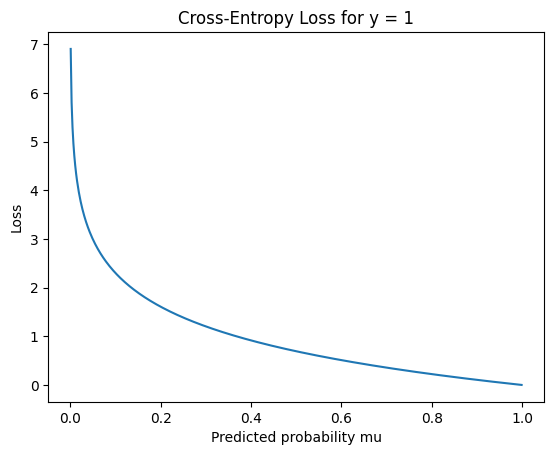

In [3104]:
mu_values = np.linspace(0.001, 0.999, 500)

# y = 1
loss_y1 = -np.log(mu_values)

plt.plot(mu_values, loss_y1)
plt.xlabel("Predicted probability mu")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss for y = 1")
plt.show()



Doing the same for when y = 0

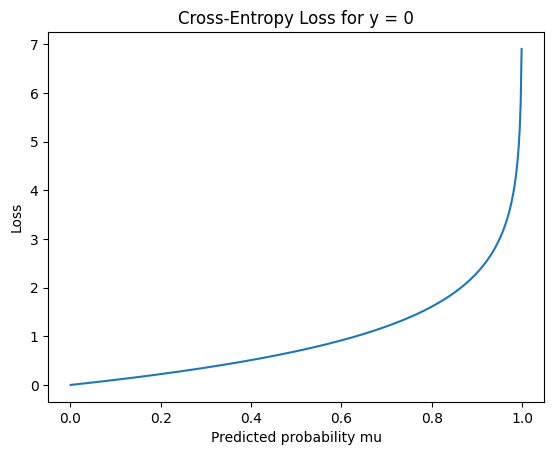

In [3105]:
mu_values = np.linspace(0.001, 0.999, 500)

# y = 0
loss_y0 = -np.log(1 - mu_values)

plt.plot(mu_values, loss_y0)
plt.xlabel("Predicted probability mu")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss for y = 0")
plt.show()

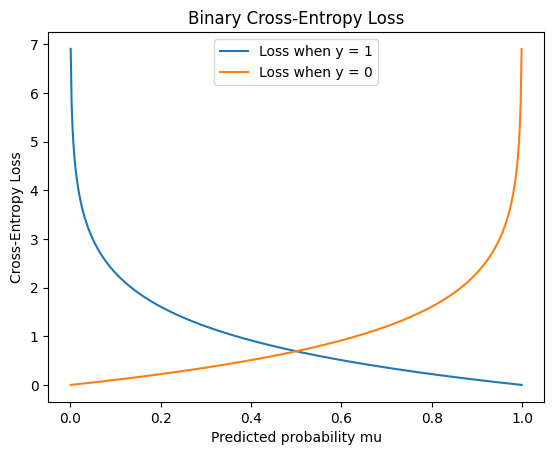

In [3106]:
mu_values = np.linspace(0.001, 0.999, 500)

loss_y1 = -np.log(mu_values)
loss_y0 = -np.log(1 - mu_values)

plt.plot(mu_values, loss_y1, label="Loss when y = 1")
plt.plot(mu_values, loss_y0, label="Loss when y = 0")

plt.xlabel("Predicted probability mu")
plt.ylabel("Cross-Entropy Loss")
plt.title("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

## Logistic NLL using X, y and w

In [3107]:
def logistic_nll(X, y, w):
    logits = X @ w
    mu = sigmoid(logits)

    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss

### testing on simple fake data

In [3108]:
np.random.seed(0)

# simple 2D data
n = 100

X_features = np.random.randn(n, 2)

# add bias column
X = np.c_[np.ones(n), X_features]

# fake binary labels
y = np.random.randint(0, 2, size=n)

# initialize weights
w = np.zeros(X.shape[1])

loss = logistic_nll(X, y, w)

print("Initial loss:", loss)

Initial loss: 0.6931471805599436


Accuracy: 1.0
NLL: 0.050661782278427075


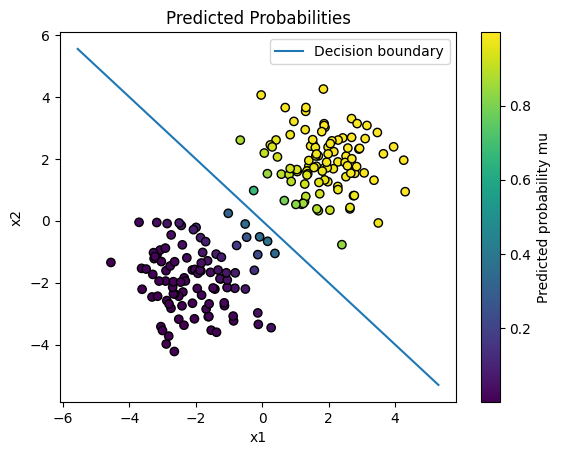

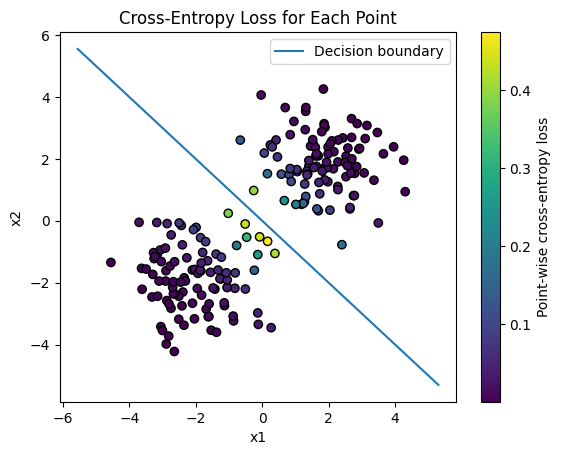

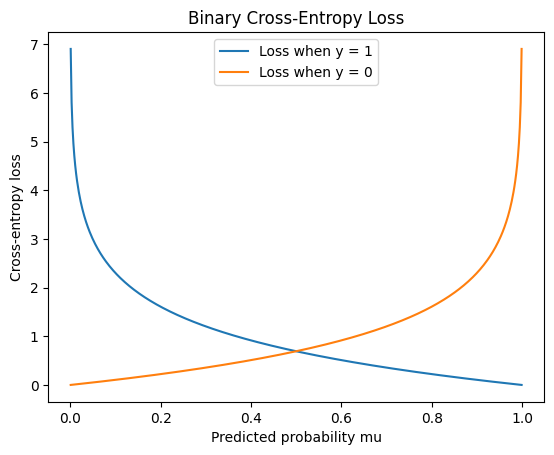

In [3109]:
# all together
def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def binary_cross_entropy(y, mu):
    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss


np.random.seed(0)

n_per_class = 100

X0 = np.random.randn(n_per_class, 2) + np.array([-2, -2])
X1 = np.random.randn(n_per_class, 2) + np.array([2, 2])

X_features = np.vstack([X0, X1])
y = np.array([0] * n_per_class + [1] * n_per_class)

X = np.c_[np.ones(len(X_features)), X_features]

# hand-picked weights
w = np.array([0.0, 1.0, 1.0])

# forward pass
logits = X @ w
mu = sigmoid(logits)
y_pred = (mu >= 0.5).astype(int)

accuracy = np.mean(y_pred == y)
nll = binary_cross_entropy(y, mu)

print("Accuracy:", accuracy)
print("NLL:", nll)

# decision boundary
x1_values = np.linspace(X_features[:, 0].min() - 1, X_features[:, 0].max() + 1, 100)
x2_values = -(w[0] + w[1] * x1_values) / w[2]

# point-wise losses
epsilon = 1e-15
point_losses = -(
    y * np.log(mu + epsilon)
    + (1 - y) * np.log(1 - mu + epsilon)
)

# plot predicted probabilities
plt.scatter(X_features[:, 0], X_features[:, 1], c=mu, edgecolor="k")
plt.colorbar(label="Predicted probability mu")
plt.plot(x1_values, x2_values, label="Decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Predicted Probabilities")
plt.legend()
plt.show()

# plot point-wise losses
plt.scatter(X_features[:, 0], X_features[:, 1], c=point_losses, edgecolor="k")
plt.colorbar(label="Point-wise cross-entropy loss")
plt.plot(x1_values, x2_values, label="Decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Cross-Entropy Loss for Each Point")
plt.legend()
plt.show()

# plot CE loss curves
mu_values = np.linspace(0.001, 0.999, 500)

loss_y1 = -np.log(mu_values)
loss_y0 = -np.log(1 - mu_values)

plt.plot(mu_values, loss_y1, label="Loss when y = 1")
plt.plot(mu_values, loss_y0, label="Loss when y = 0")
plt.xlabel("Predicted probability mu")
plt.ylabel("Cross-entropy loss")
plt.title("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

# Logistic Regression Part 3: Gradient Descent from the Hand-Derived Gradient

## Goal

Now that we understand the logistic regression forward pass and cross-entropy loss, we want to train the model using gradient descent.

The model computes a logit:

$$
a_n = w^\top x_n
$$

Then applies the sigmoid:

$$
\mu_n = \sigma(a_n) = \frac{1}{1 + e^{-a_n}}
$$

where:

$$
\mu_n = p(y_n = 1 \mid x_n)
$$

The prediction is:

$$
\hat{y}_n = \mathbf{1}(a_n > 0)
$$

---

## Negative Log-Likelihood

The binary cross-entropy loss, also called negative log-likelihood, is:

$$
NLL(w) =
-\frac{1}{N}
\sum_{n=1}^{N}
\left[
y_n\log(\mu_n) + (1-y_n)\log(1-\mu_n)
\right]
$$

where:

$$
\mu_n = \sigma(w^\top x_n)
$$

The goal is to minimize this loss:

$$
\hat{w} = \arg\min_w NLL(w)
$$

Unlike linear regression, there is no closed-form solution because `w` is inside the sigmoid function.

So we use gradient descent.

---

## Gradient of the NLL

From the notes, the gradient of the negative log-likelihood simplifies to:

$$
\nabla_w NLL(w)
=
\frac{1}{N}
\sum_{n=1}^{N}
(\mu_n - y_n)x_n
$$

In matrix form:

$$
\nabla_w NLL(w)
=
\frac{1}{N}X^\top(\mu - y)
$$

where:

$$
\mu = \sigma(Xw)
$$

This is the main gradient we will use.

---

## Gradient Descent Update

Gradient descent updates the weights by moving in the opposite direction of the gradient:

$$
w := w - \eta \nabla_w NLL(w)
$$

Substituting the logistic regression gradient:

$$
w := w - \eta \frac{1}{N}X^\top(\mu - y)
$$

where:

- `eta` is the learning rate
- `mu` is the predicted probability
- `y` is the true label
- `mu - y` is the prediction error

---

## Connection to Linear Regression

For linear regression, the MSE gradient looked like:

$$
\nabla_w MSE(w) = \frac{2}{N}X^\top(\hat{y} - y)
$$

For logistic regression, the gradient is:

$$
\nabla_w NLL(w) = \frac{1}{N}X^\top(\mu - y)
$$

The structure is almost the same:

$$
X^\top(\text{prediction} - \text{target})
$$

The only difference is the prediction:

```python
linear regression:   y_pred = X @ w
logistic regression: mu = sigmoid(X @ w)
```

So the same gradient descent idea carries over.

---

## Gradient Checking

Before trusting our gradient, we can check it numerically using finite differences.

For one component `w_j`, the finite-difference estimate is:

$$
\frac{L(w + \epsilon e_j) - L(w - \epsilon e_j)}{2\epsilon}
$$

where:

- `epsilon` is a very small number
- `e_j` is a vector with `1` in position `j` and `0` elsewhere

If our analytic gradient is correct, it should match the finite-difference gradient closely.

This is called a **gradient check**.

---

## Main Idea

Logistic regression is trained by repeatedly doing:

```python
logits = X @ w
mu = sigmoid(logits)
gradient = (1 / N) * X.T @ (mu - y)
w = w - learning_rate * gradient
```

The model improves because each update reduces the cross-entropy loss.

Since the logistic regression loss is convex, gradient descent can reach the global optimum if the learning rate is chosen properly.

In [3110]:
def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def logistic_nll(X, y, w):
    logits = X @ w
    mu = sigmoid(logits)

    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss


def logistic_gradient(X, y, w):
    n = len(y)

    logits = X @ w
    mu = sigmoid(logits)

    gradient = (1 / n) * X.T @ (mu - y)

    return gradient

Train with full-batch gradient descent: 


In [3111]:
def logistic_gradient_descent(X, y, learning_rate=0.1, epochs=1000):
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

        gradient = logistic_gradient(X, y, w)

        w = w - learning_rate * gradient

    return w, loss_history

using 2D blob dataset from before. 

In [3112]:
np.random.seed(0)

n_per_class = 100

X0 = np.random.randn(n_per_class, 2) + np.array([-2, -2])
X1 = np.random.randn(n_per_class, 2) + np.array([2, 2])

X_features = np.vstack([X0, X1])
y = np.array([0] * n_per_class + [1] * n_per_class)

X = np.c_[np.ones(len(X_features)), X_features]



Train the model

In [3113]:
w, loss_history = logistic_gradient_descent(X, y, learning_rate = 0.1, epochs = 1000)

print("Learned weights: ", w)
print("Final Loss:", loss_history[-1])

Learned weights:  [-0.24842212  2.02951276  2.20098483]
Final Loss: 0.009595525760789122


### Plotting the loss

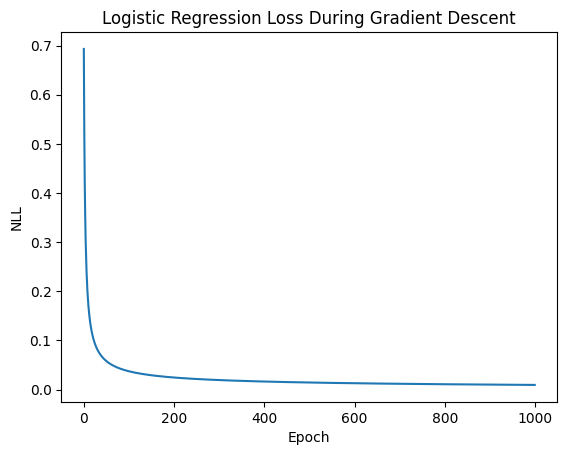

In [3114]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Logistic Regression Loss During Gradient Descent")
plt.show()

### Computing the accuracy 

In [3115]:
logits = X @ w
mu = sigmoid(logits)
y_pred = (mu >= 0.5).astype(int)

accuracy = np.mean(y_pred == y)

print("Accuracy: ", accuracy)

Accuracy:  1.0


### Gradient Checking. 

Compare hand-derived analytic gradient to a numerical finite - difference approximation

In [3116]:
def finite_difference_gradient(X, y, w, epsilon=1e-5):
    numerical_gradient = np.zeros_like(w)

    for j in range(len(w)):
        w_plus = w.copy()
        w_minus = w.copy()

        w_plus[j] += epsilon
        w_minus[j] -= epsilon

        loss_plus = logistic_nll(X, y, w_plus)
        loss_minus = logistic_nll(X, y, w_minus)

        numerical_gradient[j] = (loss_plus - loss_minus) / (2 * epsilon)

    return numerical_gradient

### Testing

In [3117]:
# choose a random weight vector to test
np.random.seed(1)
w_test = np.random.randn(X.shape[1])

# analytic gradient from calculus
analytic_grad = logistic_gradient(X, y, w_test)

# numerical gradient from finite differences
numerical_grad = finite_difference_gradient(X, y, w_test)

print("Analytic gradient:")
print(analytic_grad)

print("\nNumerical gradient:")
print(numerical_grad)

print("\nDifference:")
print(analytic_grad - numerical_grad)

print("\nMax absolute difference:")
print(np.max(np.abs(analytic_grad - numerical_grad)))

Analytic gradient:
[ 0.17986779 -1.60458088 -1.52951504]

Numerical gradient:
[ 0.17986779 -1.60458088 -1.52951504]

Difference:
[ 2.53634058e-11 -4.04087874e-11 -1.67563741e-11]

Max absolute difference:
4.040878742728182e-11


In [3118]:
for j in range(len(w_test)):
    print(f"w[{j}]")
    print("analytic: ", analytic_grad[j])
    print("numeric:  ", numerical_grad[j])
    print("diff:     ", abs(analytic_grad[j] - numerical_grad[j]))
    print()

w[0]
analytic:  0.17986779166406264
numeric:   0.17986779163869923
diff:      2.5363405820044704e-11

w[1]
analytic:  -1.604580882071268
numeric:   -1.6045808820308591
diff:      4.040878742728182e-11

w[2]
analytic:  -1.5295150377071438
numeric:   -1.5295150376903874
diff:      1.6756374066062563e-11



Essentially you want the max absolute different to be very small which it is as shown above. 

# Logistic Regression Part 4: Stochastic and Mini-Batch Gradient Descent

## Goal

So far, we trained logistic regression using **full-batch gradient descent**.

In full-batch gradient descent, every update uses the entire dataset:

$$
\nabla_w NLL(w) = \frac{1}{N}X^\top(\mu - y)
$$

where:

$$
\mu = \sigma(Xw)
$$

The update rule is:

$$
w := w - \eta \nabla_w NLL(w)
$$

This is stable, but for large datasets, using all examples for every update can be slow.

Real machine learning systems usually use **stochastic gradient descent** or **mini-batch gradient descent**.

---

## Full-Batch Gradient Descent

Full-batch gradient descent uses all `N` examples before making one update.

```python
gradient = (1 / n) * X.T @ (mu - y)
w = w - learning_rate * gradient
```

This gives a smooth loss curve because each gradient is computed using the entire dataset.

---

## Stochastic Gradient Descent

Stochastic Gradient Descent, or `SGD`, updates the weights using one example at a time.

For one example:

$$
a_n = w^\top x_n
$$

$$
\mu_n = \sigma(a_n)
$$

The gradient for one example is:

$$
(\mu_n - y_n)x_n
$$

So the SGD update is:

$$
w := w - \eta(\mu_n - y_n)x_n
$$

In code:

```python
mu_i = sigmoid(xi @ w)
gradient = (mu_i - yi) * xi
w = w - learning_rate * gradient
```

SGD is faster per update, but the loss curve is noisier because each update is based on only one data point.

---

## Mini-Batch Gradient Descent

Mini-batch gradient descent is a compromise between full-batch GD and SGD.

Instead of using all data points or one data point, it uses a small batch, usually something like `16`, `32`, `64`, or `128`.

For a mini-batch:

$$
\nabla_w NLL(w)
=
\frac{1}{m}X_{batch}^\top(\mu_{batch} - y_{batch})
$$

where `m` is the batch size.

In code:

```python
mu_batch = sigmoid(X_batch @ w)
gradient = (1 / len(y_batch)) * X_batch.T @ (mu_batch - y_batch)
w = w - learning_rate * gradient
```

Mini-batch GD is commonly used in practice because it is faster than full-batch GD and less noisy than pure SGD.

---

## Learning Rate Schedule

For SGD, the learning rate often needs to decay over time.

A simple schedule is:

$$
\eta_t = \frac{\eta_0}{1 + decay \cdot t}
$$

where:

- `eta_0` is the initial learning rate
- `decay` controls how quickly the learning rate shrinks
- `t` is the update step

In code:

```python
lr_t = initial_learning_rate / (1 + decay * t)
```

At the beginning, the learning rate is larger, so the model learns quickly.

Later, the learning rate becomes smaller, so the model can settle near the minimum instead of bouncing around.

---

## Main Comparison

| Method | Data per update | Loss curve | Practical use |
|---|---:|---|---|
| Full-batch GD | All data | Smoothest | Good for small datasets |
| SGD | 1 example | Noisiest | Fast updates, but unstable |
| Mini-batch GD | Small batch | Moderately smooth | Most common in real ML |

---

## Main Idea

The gradient always has the same structure:

$$
X^\top(\text{prediction} - \text{target})
$$

The difference is how many examples we use to estimate the gradient.

Full-batch uses all examples.

SGD uses one example.

Mini-batch uses a small group of examples.

The update rule is always:

$$
w := w - \eta \cdot gradient
$$

## Full-Batch gradient descent 

In [3119]:
def full_batch_logistic_gd(X, y, learning_rate=0.1, epochs=1000):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        logits = X @ w
        mu = sigmoid(logits)

        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

        gradient = (1 / n) * X.T @ (mu - y)

        w = w - learning_rate * gradient

    return w, loss_history

## Stochatic Gradient Descent

In [3120]:
def stochastic_logistic_gd(X, y, learning_rate=0.1, epochs=50):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)

        for i in indices:
            xi = X[i]
            yi = y[i]

            logit_i = xi @ w
            mu_i = sigmoid(logit_i)

            gradient = (mu_i - yi) * xi

            w = w - learning_rate * gradient

        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

    return w, loss_history

## Mini-Batch Gradient Descent

In [3121]:
def mini_batch_logistic_gd(X, y, learning_rate=0.1, epochs=100, batch_size=32):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start_idx in range(0, n, batch_size):
            end_idx = start_idx + batch_size

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            mu_batch = sigmoid(X_batch @ w)

            gradient = (1 / len(y_batch)) * X_batch.T @ (mu_batch - y_batch)

            w = w - learning_rate * gradient

        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

    return w, loss_history

## SGD with decaying learning rate

In [3122]:
def stochastic_logistic_gd_decay(X, y, initial_learning_rate=0.1, decay=0.001, epochs=50):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []

    step = 0

    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)

        for i in indices:
            xi = X[i]
            yi = y[i]

            logit_i = xi @ w
            mu_i = sigmoid(logit_i)

            gradient = (mu_i - yi) * xi

            learning_rate_t = initial_learning_rate / (1 + decay * step)

            w = w - learning_rate_t * gradient

            step += 1

        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

    return w, loss_history

## Running all methods 

In [3123]:
w_full, loss_full = full_batch_logistic_gd(
    X,
    y,
    learning_rate=0.1,
    epochs=1000
)

w_sgd, loss_sgd = stochastic_logistic_gd(
    X,
    y,
    learning_rate=0.01,
    epochs=50
)

w_mini, loss_mini = mini_batch_logistic_gd(
    X,
    y,
    learning_rate=0.05,
    epochs=100,
    batch_size=32
)

w_sgd_decay, loss_sgd_decay = stochastic_logistic_gd_decay(
    X,
    y,
    initial_learning_rate=0.05,
    decay=0.001,
    epochs=50
)

## Plotting + Accuracies 

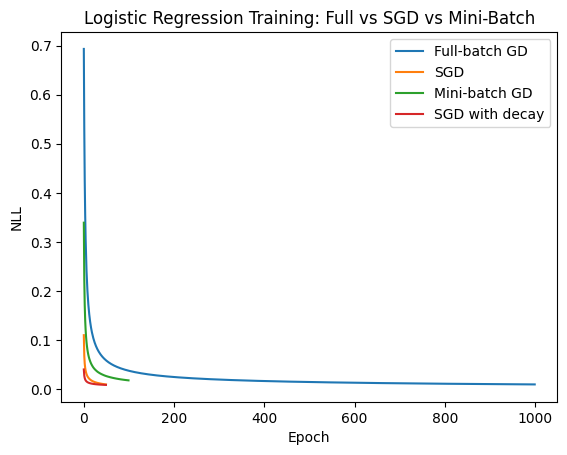

Full-batch accuracy: 1.0
SGD accuracy: 1.0
Mini-batch accuracy: 1.0
SGD with decay accuracy: 1.0


In [3124]:
plt.plot(loss_full, label="Full-batch GD")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mini, label="Mini-batch GD")
plt.plot(loss_sgd_decay, label="SGD with decay")

plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Logistic Regression Training: Full vs SGD vs Mini-Batch")
plt.legend()
plt.show()

def accuracy_score(X, y, w):
    mu = sigmoid(X @ w)
    y_pred = (mu >= 0.5).astype(int)
    return np.mean(y_pred == y)


print("Full-batch accuracy:", accuracy_score(X, y, w_full))
print("SGD accuracy:", accuracy_score(X, y, w_sgd))
print("Mini-batch accuracy:", accuracy_score(X, y, w_mini))
print("SGD with decay accuracy:", accuracy_score(X, y, w_sgd_decay))

## Using more complex data

In [3125]:
np.random.seed(42)

n_per_class = 300

# more overlap: centers are closer making the variance is larger
X0 = np.random.randn(n_per_class, 2) * 1.6 + np.array([-1.2, -1.2])
X1 = np.random.randn(n_per_class, 2) * 1.6 + np.array([1.2, 1.2])

X_features = np.vstack([X0, X1])
y = np.array([0] * n_per_class + [1] * n_per_class)

# flip some labels to add noise
flip_rate = 0.08
num_flips = int(flip_rate * len(y))

flip_indices = np.random.choice(len(y), size=num_flips, replace=False)
y[flip_indices] = 1 - y[flip_indices]

# add bias column
X = np.c_[np.ones(len(X_features)), X_features]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of flipped labels:", num_flips)

X shape: (600, 3)
y shape: (600,)
Number of flipped labels: 48


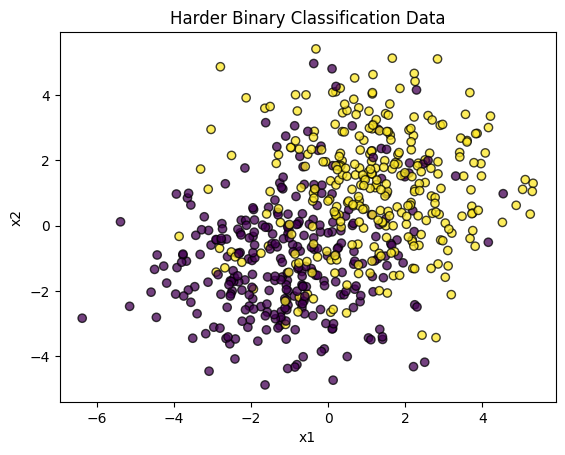

In [3126]:
# Plotting this 
plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Harder Binary Classification Data")
plt.show()

Notice here in this case there is more overlap between data making classifying much more harder as well. 

## Running all methods On Complex Data

In [3127]:
w_full, loss_full = full_batch_logistic_gd(
    X, y,
    learning_rate=0.1,
    epochs=1000
)

w_sgd, loss_sgd = stochastic_logistic_gd(
    X, y,
    learning_rate=0.01,
    epochs=50
)

w_mini, loss_mini = mini_batch_logistic_gd(
    X, y,
    learning_rate=0.05,
    epochs=100,
    batch_size=32
)

w_sgd_decay, loss_sgd_decay = stochastic_logistic_gd_decay(
    X, y,
    initial_learning_rate=0.05,
    decay=0.001,
    epochs=50
)

## Plotting Curves + Accuracy 

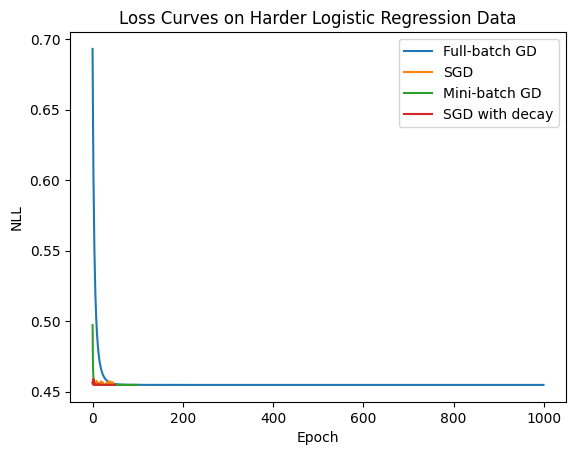

Full-batch accuracy: 0.81
SGD accuracy: 0.81
Mini-batch accuracy: 0.81
SGD with decay accuracy: 0.8116666666666666


In [3128]:
plt.plot(loss_full, label="Full-batch GD")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mini, label="Mini-batch GD")
plt.plot(loss_sgd_decay, label="SGD with decay")

plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Loss Curves on Harder Logistic Regression Data")
plt.legend()
plt.show()

print("Full-batch accuracy:", accuracy_score(X, y, w_full))
print("SGD accuracy:", accuracy_score(X, y, w_sgd))
print("Mini-batch accuracy:", accuracy_score(X, y, w_mini))
print("SGD with decay accuracy:", accuracy_score(X, y, w_sgd_decay))

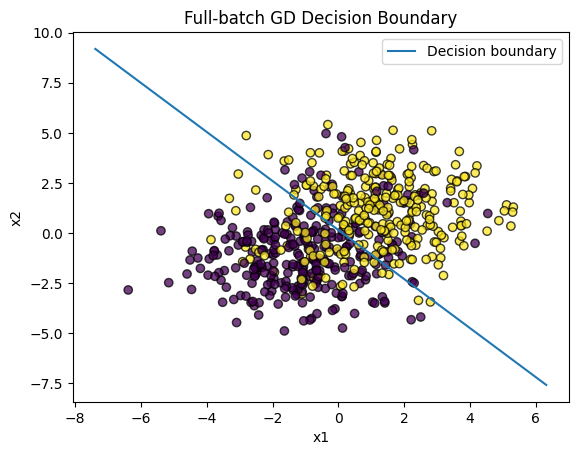

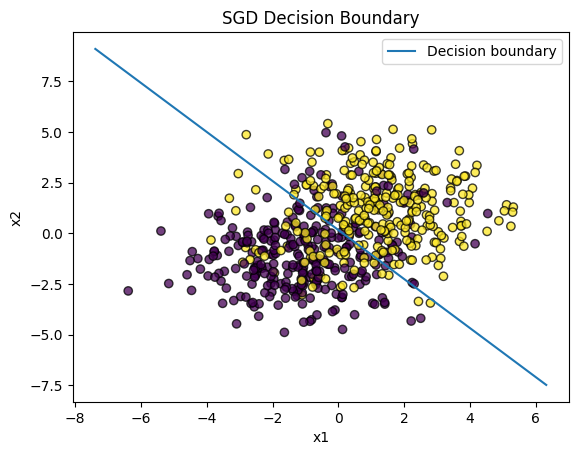

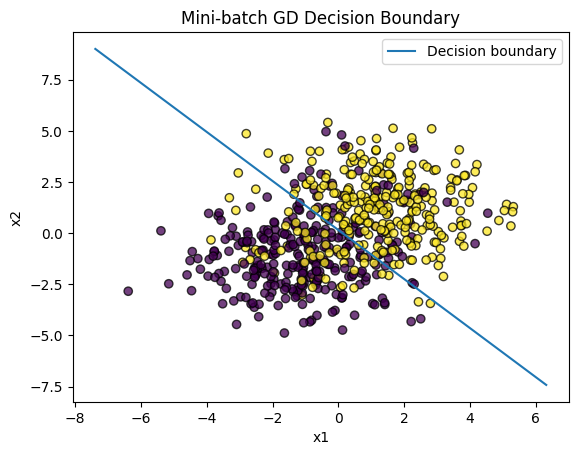

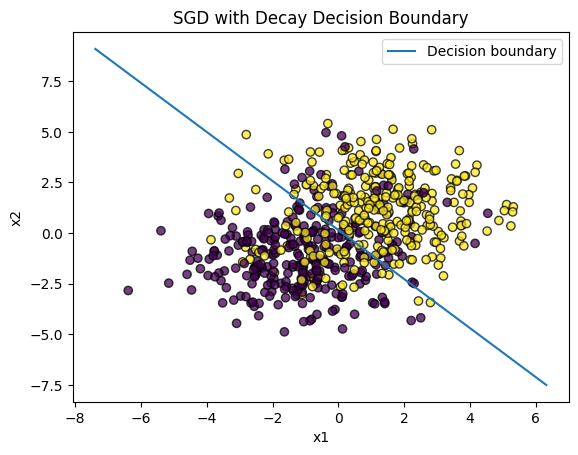

In [3129]:
# Decision Boundaries 

def plot_decision_boundary(X_features, y, w, title):
    plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k", alpha=0.75)

    x1_values = np.linspace(X_features[:, 0].min() - 1, X_features[:, 0].max() + 1, 200)

    # boundary: w0 + w1*x1 + w2*x2 = 0
    x2_values = -(w[0] + w[1] * x1_values) / w[2]

    plt.plot(x1_values, x2_values, label="Decision boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()


plot_decision_boundary(X_features, y, w_full, "Full-batch GD Decision Boundary")
plot_decision_boundary(X_features, y, w_sgd, "SGD Decision Boundary")
plot_decision_boundary(X_features, y, w_mini, "Mini-batch GD Decision Boundary")
plot_decision_boundary(X_features, y, w_sgd_decay, "SGD with Decay Decision Boundary")

# Logistic Regression Part 5: Newton's Method and IRLS

## Goal

So far, we trained logistic regression using gradient descent.

Gradient descent is a first-order method because it only uses the gradient:

$$
\nabla_w NLL(w)
$$

Newton's method is a second-order method because it uses both the gradient and the Hessian:

$$
\nabla_w^2 NLL(w)
$$

The Hessian contains curvature information. This allows Newton's method to take better steps and often converge in far fewer iterations than gradient descent.

---

## Gradient

For logistic regression, the negative log-likelihood gradient is:

$$
g(w) = \nabla_w NLL(w)
= \frac{1}{N}X^\top(\mu - y)
$$

where:

$$
\mu = \sigma(Xw)
$$

---

## Hessian

The Hessian is:

$$
H(w) = \nabla_w^2 NLL(w)
= \frac{1}{N}X^\top S X
$$

where:

$$
S = \text{diag}(\mu_1(1-\mu_1), \dots, \mu_N(1-\mu_N))
$$

Each diagonal entry of `S` is:

$$
S_{nn} = \mu_n(1-\mu_n)
$$

This term is largest when:

$$
\mu_n = 0.5
$$

and becomes small when:

$$
\mu_n \approx 0
$$

or:

$$
\mu_n \approx 1
$$

So when the model becomes extremely confident, the Hessian can become nearly singular.

---

## Newton Update

Newton's method updates the weights using:

$$
w := w - H^{-1}g
$$

In practice, we should not explicitly compute the inverse. Instead of writing:

```python
step = np.linalg.inv(H) @ g
```

we solve the linear system:

```python
step = np.linalg.solve(H, g)
```

Then update:

```python
w = w - step
```

This is more numerically stable.

---

## Why Newton Can Be Faster

Gradient descent uses:

$$
w := w - \eta g
$$

It only knows the slope.

Newton's method uses:

$$
w := w - H^{-1}g
$$

It uses both slope and curvature.

Because of this, Newton's method often converges in around `5` to `10` iterations, while gradient descent may need hundreds or thousands.

---

## IRLS Interpretation

Newton's method for logistic regression can also be written as Iteratively Reweighted Least Squares, or `IRLS`.

At each iteration, the method creates a weighted least-squares problem using:

$$
S_t = \text{diag}(\mu_{t,n}(1-\mu_{t,n}))
$$

and a working response:

$$
z_t = Xw_t + S_t^{-1}(y-\mu_t)
$$

Then the update can be written as:

$$
w_{t+1} = (X^\top S_t X)^{-1}X^\top S_t z_t
$$

The important idea is:

```text
Newton / IRLS repeatedly solves weighted least-squares problems.
The weights S are recomputed every iteration.
```

---

## Practical Caveat

If the data is nearly linearly separable, the model can become very confident:

$$
\mu_n \to 0
$$

or:

$$
\mu_n \to 1
$$

Then:

$$
\mu_n(1-\mu_n) \to 0
$$

So the diagonal entries of `S` become very small.

This makes the Hessian:

$$
H = \frac{1}{N}X^\top S X
$$

nearly singular.

That means Newton's method can become unstable on separable or nearly separable data.

---

## Main Idea

Gradient descent uses only the gradient:

$$
w := w - \eta g
$$

Newton's method uses curvature:

$$
w := w - H^{-1}g
$$

Newton usually converges much faster, but each step is more expensive and can become unstable when the Hessian is nearly singular.

In [3130]:
def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def logistic_nll(X, y, w):
    logits = X @ w
    mu = sigmoid(logits)

    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss


def logistic_gradient(X, y, w):
    n = len(y)

    mu = sigmoid(X @ w)
    gradient = (1 / n) * X.T @ (mu - y)

    return gradient

## Hessian

In [3131]:
def logistic_hessian(X, y, w):
    n = len(y)

    mu = sigmoid(X @ w)

    # diagonal entries of S
    s = mu * (1 - mu)

    # efficient version of X.T @ S @ X
    H = (1 / n) * X.T @ (s[:, None] * X)

    return H

The line: 

```python
s[:, None] * X
```

multiplies each row of X by its corresponding weight s_n.

So it is equivalent to:

S @ X





## Check to see if Hessian is PD

In [3132]:
w_test = np.zeros(X.shape[1])

H = logistic_hessian(X, y, w_test)

eigenvalues = np.linalg.eigvals(H)

print("Hessian eigenvalues:")
print(eigenvalues)

print("Minimum eigenvalue:", np.min(eigenvalues))

Hessian eigenvalues:
[0.24950819 1.42469853 0.64675225]
Minimum eigenvalue: 0.24950818685948062


Since all eigenvalues are positive, the matrix is PD. 

## Newton's Method

In [3133]:
def newton_logistic_regression(X, y, epochs=20, tolerance=1e-8):
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

        g = logistic_gradient(X, y, w)
        H = logistic_hessian(X, y, w)

        # solve H step = g
        step = np.linalg.solve(H, g)

        # Newton update
        w = w - step

        # stop if step is tiny
        if np.linalg.norm(step) < tolerance:
            print(f"Converged at epoch {epoch}")
            break

    return w, loss_history

In [3134]:
# running it 
w_newton, loss_newton = newton_logistic_regression(
    X,
    y,
    epochs=20
)

print("Newton weights:", w_newton)
print("Final Newton loss:", loss_newton[-1])

Converged at epoch 5
Newton weights: [-0.07651383  0.61560762  0.50320408]
Final Newton loss: 0.45474804140610825


## Comparing to Gradient Descent 

In [3135]:
def full_batch_logistic_gd(X, y, learning_rate=0.1, epochs=1000):
    n = len(y)
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        mu = sigmoid(X @ w)

        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

        gradient = (1 / n) * X.T @ (mu - y)

        w = w - learning_rate * gradient

    return w, loss_history

w_gd, loss_gd = full_batch_logistic_gd(
    X,
    y,
    learning_rate=0.1,
    epochs=1000
)

print("GD weights:", w_gd)
print("Final GD loss:", loss_gd[-1])

GD weights: [-0.07651379  0.61560762  0.50320408]
Final GD loss: 0.4547480414061084


## Plotting Loss

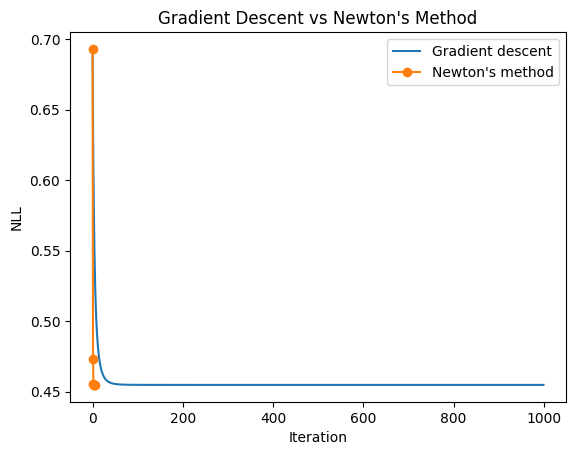

In [3136]:
plt.plot(loss_gd, label="Gradient descent")
plt.plot(loss_newton, marker="o", label="Newton's method")

plt.xlabel("Iteration")
plt.ylabel("NLL")
plt.title("Gradient Descent vs Newton's Method")
plt.legend()
plt.show()

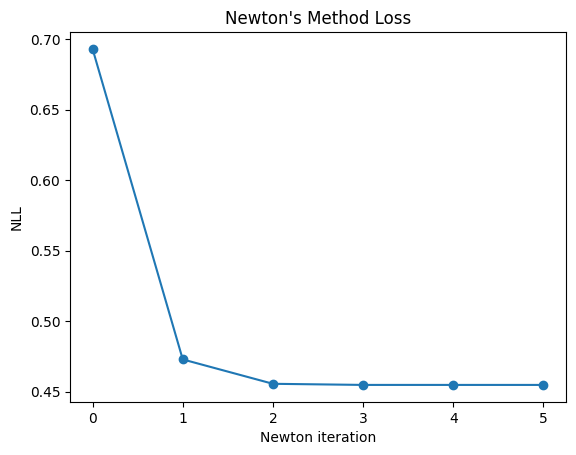

In [3137]:
plt.plot(loss_newton, marker="o")

plt.xlabel("Newton iteration")
plt.ylabel("NLL")
plt.title("Newton's Method Loss")
plt.show()

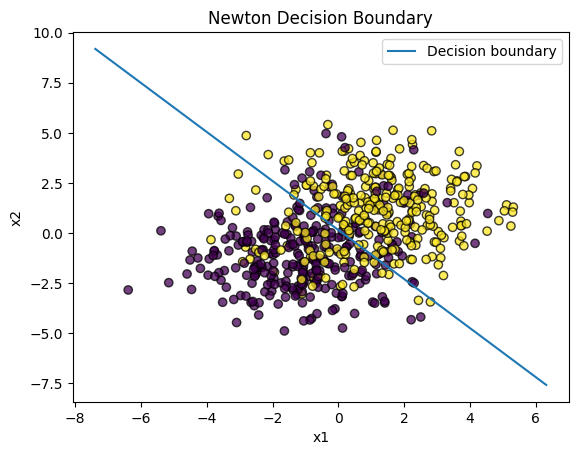

In [3138]:
def plot_decision_boundary(X_features, y, w, title):
    plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k", alpha=0.75)

    x1_values = np.linspace(X_features[:, 0].min() - 1, X_features[:, 0].max() + 1, 200)

    # boundary: w0 + w1*x1 + w2*x2 = 0
    x2_values = -(w[0] + w[1] * x1_values) / w[2]

    plt.plot(x1_values, x2_values, label="Decision boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()


plot_decision_boundary(X_features, y, w_newton, "Newton Decision Boundary")

In [3139]:
mu = sigmoid(X @ w_newton)
s = mu * (1 - mu)

print("Smallest S value:", np.min(s))
print("Largest S value:", np.max(s))
print("Mean S value:", np.mean(s))

Smallest S value: 0.004317412456339818
Largest S value: 0.2499999732625022
Mean S value: 0.1469510283912341


# Logistic Regression Part 6: Regularization, Separability Blow-Up, and Standardization

## Goal

In logistic regression, if the data is perfectly linearly separable, the maximum likelihood estimate can behave badly.

The model can keep increasing the size of the weights, making the sigmoid sharper and sharper.

The decision boundary may stop changing much, but the confidence keeps increasing.

This means:

```python
||w|| grows
NLL decreases toward 0
weights do not settle
```

This is called the **separability blow-up** problem.

---

## Why Separable Data Causes Blow-Up

Logistic regression predicts:

$$
\mu_n = \sigma(w^\top x_n)
$$

If the data is perfectly separable, the model can make all correct-class probabilities closer and closer to `1`.

For a correctly classified point with label `1`, the model wants:

$$
\mu_n \to 1
$$

For a correctly classified point with label `0`, the model wants:

$$
\mu_n \to 0
$$

The NLL keeps improving as the model becomes more confident.

So the weights can grow very large:

$$
\|w\| \to \infty
$$

while the decision boundary itself barely changes.

---

## L2 Regularization

To prevent weights from growing without bound, we add an L2 penalty.

The regularized objective is:

$$
PNLL(w) = NLL(w) + \lambda \|w\|_2^2
$$

where:

$$
\|w\|_2^2 = w^\top w
$$

The value `lambda` controls the strength of regularization.

```text
larger lambda  -> stronger penalty  -> smaller weights
smaller lambda -> weaker penalty    -> larger weights
```

In the MAP interpretation, this corresponds to placing a zero-mean Gaussian prior on the weights.

Your notes write:

$$
\lambda = \frac{1}{C}
$$

where `C` is the prior variance.

So:

```text
larger C  -> weaker regularization
smaller C -> stronger regularization
```

---

## Do Not Penalize the Bias

Usually, we do not regularize the bias/intercept term.

If:

```python
w[0]   # bias/intercept
w[1:]  # feature weights
```

then the L2 penalty should only apply to:

```python
w[1:]
```

So in code:

```python
penalty = lambda_value * np.sum(w[1:] ** 2)
```

---

## Regularized Gradient

For unregularized logistic regression, the gradient is:

$$
g(w) = \frac{1}{N}X^\top(\mu - y)
$$

For L2-regularized logistic regression:

$$
\nabla_w PNLL(w) = g(w) + 2\lambda w
$$

But if we do not penalize the bias, we only add the penalty gradient to `w[1:]`:

```python
gradient = (1 / n) * X.T @ (mu - y)
gradient[1:] += 2 * lambda_value * w[1:]
```

---

## Regularized Hessian

The unregularized Hessian is:

$$
H(w) = \frac{1}{N}X^\top S X
$$

where:

$$
S = \text{diag}(\mu_n(1-\mu_n))
$$

With L2 regularization:

$$
\nabla_w^2 PNLL(w) = H(w) + 2\lambda I
$$

Again, if we do not regularize the bias, we should not add the penalty to the intercept entry.

In code:

```python
H_reg = H.copy()
H_reg[1:, 1:] += 2 * lambda_value * np.eye(X.shape[1] - 1)
```

---

## Standardization

Standardization rescales each feature to have mean `0` and standard deviation `1`:

$$
x_{nd}^{standardized} = \frac{x_{nd} - \hat{\mu}_d}{\hat{\sigma}_d}
$$

In code:

```python
X_scaled = (X_features - X_features.mean(axis=0)) / X_features.std(axis=0)
```

This matters for two reasons.

First, it improves optimization. If one feature is much larger than another, gradient descent can move slowly or unstably.

Second, it makes L2 regularization more meaningful. L2 regularization penalizes all weights equally, so the features should be on comparable scales.

If one feature is measured in units of `1` and another is measured in units of `1000`, then equal weight penalties are not really fair.

---

## Main Idea

Unregularized logistic regression can blow up on separable data:

```python
||w|| keeps growing
NLL keeps decreasing
weights do not stabilize
```

L2 regularization fixes this by adding a penalty:

```python
PNLL = NLL + lambda * ||w||^2
```

Standardization makes optimization faster and makes the L2 penalty more meaningful.

In [3140]:
# helper function 
def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def logistic_nll(X, y, w):
    logits = X @ w
    mu = sigmoid(logits)

    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss


def logistic_gradient(X, y, w):
    n = len(y)
    mu = sigmoid(X @ w)
    gradient = (1 / n) * X.T @ (mu - y)
    return gradient


def accuracy_score(X, y, w):
    mu = sigmoid(X @ w)
    y_pred = (mu >= 0.5).astype(int)
    return np.mean(y_pred == y)

## Perfectly Separable Data 

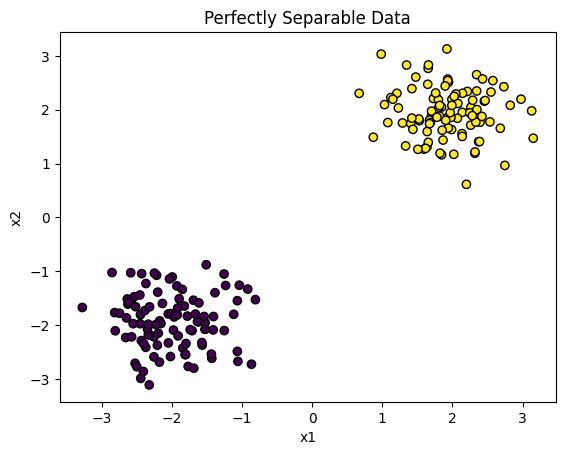

In [3141]:
np.random.seed(0)

n_per_class = 100

X0 = np.random.randn(n_per_class, 2) * 0.5 + np.array([-2, -2])
X1 = np.random.randn(n_per_class, 2) * 0.5 + np.array([2, 2])

X_features = np.vstack([X0, X1])
y = np.array([0] * n_per_class + [1] * n_per_class)

X = np.c_[np.ones(len(X_features)), X_features]

plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perfectly Separable Data")
plt.show()

## Plain GD and weight blow-up



In [3142]:
def logistic_gd_track_norm(X, y, learning_rate=0.1, epochs=5000):
    w = np.zeros(X.shape[1])

    loss_history = []
    norm_history = []

    for epoch in range(epochs):
        loss = logistic_nll(X, y, w)
        loss_history.append(loss)

        # do not include bias in norm
        norm_history.append(np.linalg.norm(w[1:]))

        gradient = logistic_gradient(X, y, w)
        w = w - learning_rate * gradient

    return w, loss_history, norm_history

In [3143]:
w_plain, loss_plain, norm_plain = logistic_gd_track_norm(
    X,
    y,
    learning_rate=0.1,
    epochs=5000
)

print("Plain GD weights:", w_plain)
print("Final NLL:", loss_plain[-1])
print("Final ||w||:", norm_plain[-1])
print("Accuracy:", accuracy_score(X, y, w_plain))

Plain GD weights: [-0.0414528   2.28184127  2.28922276]
Final NLL: 0.00043581440755588485
Final ||w||: 3.23214465944184
Accuracy: 1.0


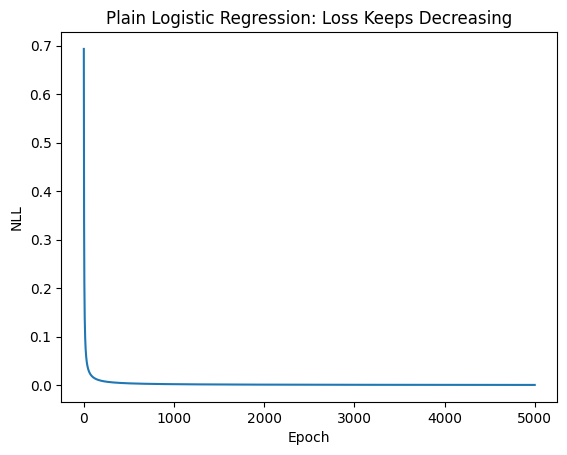

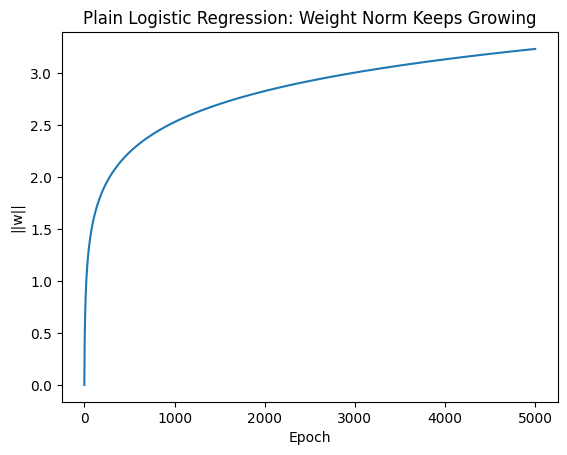

In [3144]:
plt.plot(loss_plain)
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Plain Logistic Regression: Loss Keeps Decreasing")
plt.show()

plt.plot(norm_plain)
plt.xlabel("Epoch")
plt.ylabel("||w||")
plt.title("Plain Logistic Regression: Weight Norm Keeps Growing")
plt.show()

## Add l2 regularization 


In [3145]:
def logistic_pnll_l2(X, y, w, lambda_value):
    nll = logistic_nll(X, y, w)

    # do not penalize bias
    penalty = lambda_value * np.sum(w[1:] ** 2)

    return nll + penalty


def logistic_gradient_l2(X, y, w, lambda_value):
    gradient = logistic_gradient(X, y, w)

    # do not regularize bias
    gradient[1:] += 2 * lambda_value * w[1:]

    return gradient

In [3146]:
def logistic_gd_l2_track_norm(X, y, lambda_value=0.1, learning_rate=0.1, epochs=5000):
    w = np.zeros(X.shape[1])

    loss_history = []
    norm_history = []

    for epoch in range(epochs):
        loss = logistic_pnll_l2(X, y, w, lambda_value)
        loss_history.append(loss)

        norm_history.append(np.linalg.norm(w[1:]))

        gradient = logistic_gradient_l2(X, y, w, lambda_value)
        w = w - learning_rate * gradient

    return w, loss_history, norm_history

## Run regularized GD

In [3147]:
w_l2, loss_l2, norm_l2 = logistic_gd_l2_track_norm(
    X,
    y,
    lambda_value=0.01,
    learning_rate=0.1,
    epochs=5000
)

print("L2 weights:", w_l2)
print("Final PNLL:", loss_l2[-1])
print("Final ||w||:", norm_l2[-1])
print("Accuracy:", accuracy_score(X, y, w_l2))

L2 weights: [-0.01300588  1.171603    1.17101817]
Final PNLL: 0.04151680091416833
Final ||w||: 1.6564833694164731
Accuracy: 1.0


## Plot comparisons

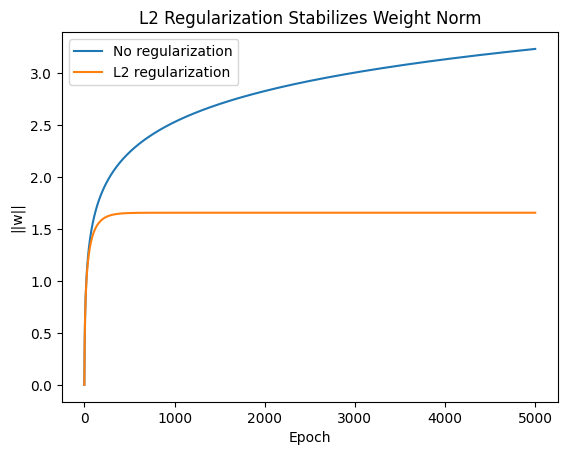

In [3148]:
plt.plot(norm_plain, label="No regularization")
plt.plot(norm_l2, label="L2 regularization")

plt.xlabel("Epoch")
plt.ylabel("||w||")
plt.title("L2 Regularization Stabilizes Weight Norm")
plt.legend()
plt.show()

## Sweep Lambda

In [3149]:
lambda_values = [0.0001, 0.001, 0.01, 0.1, 1.0]

final_norms = []
final_losses = []
final_accuracies = []
weights_by_lambda = []

for lambda_value in lambda_values:
    w_lam, loss_lam, norm_lam = logistic_gd_l2_track_norm(
        X,
        y,
        lambda_value=lambda_value,
        learning_rate=0.1,
        epochs=3000
    )

    final_norms.append(norm_lam[-1])
    final_losses.append(loss_lam[-1])
    final_accuracies.append(accuracy_score(X, y, w_lam))
    weights_by_lambda.append(w_lam)

    print("lambda:", lambda_value)
    print("weights:", w_lam)
    print("final ||w||:", norm_lam[-1])
    print("final PNLL:", loss_lam[-1])
    print("accuracy:", accuracy_score(X, y, w_lam))
    print()

lambda: 0.0001
weights: [-0.03105549  2.06575985  2.06876132]
final ||w||: 2.923431404452933
final PNLL: 0.001686012071183288
accuracy: 1.0

lambda: 0.001
weights: [-0.0339278   1.73280863  1.73909383]
final ||w||: 2.454998244417372
final PNLL: 0.008310240196783928
accuracy: 1.0

lambda: 0.01
weights: [-0.01271725  1.17161297  1.171005  ]
final ||w||: 1.6564811063272054
final PNLL: 0.04151680156282162
accuracy: 1.0

lambda: 0.1
weights: [0.00837827 0.67282065 0.66674914]
final ||w||: 0.9472286113865382
final PNLL: 0.16731907970373294
accuracy: 1.0

lambda: 1.0
weights: [0.00669012 0.25889956 0.25547171]
final ||w||: 0.3637234928045204
final PNLL: 0.4476635889147543
accuracy: 1.0



## Plot lambda vs weight norm

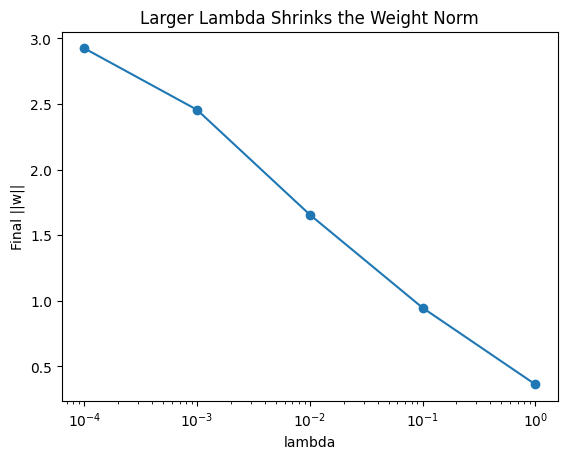

In [3150]:
plt.plot(lambda_values, final_norms, marker="o")
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("Final ||w||")
plt.title("Larger Lambda Shrinks the Weight Norm")
plt.show()

**Notes**:

- small lambda -> larger ||w||
- large lambda -> smaller ||w||

## Plot decision boundaries for different boundaries 

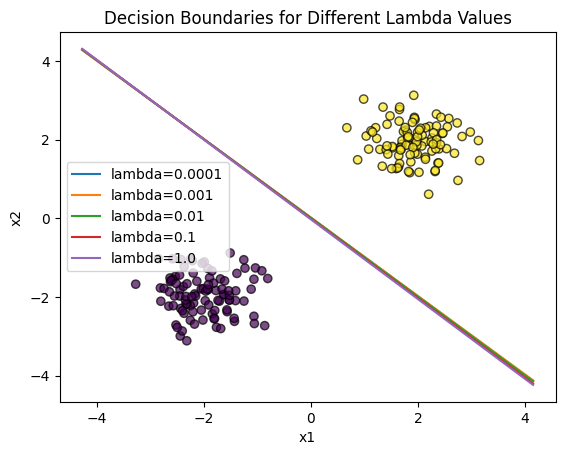

In [3151]:
def plot_decision_boundaries_for_lambdas(X_features, y, weights_by_lambda, lambda_values):
    plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k", alpha=0.7)

    x1_values = np.linspace(X_features[:, 0].min() - 1, X_features[:, 0].max() + 1, 200)

    for w, lambda_value in zip(weights_by_lambda, lambda_values):
        x2_values = -(w[0] + w[1] * x1_values) / w[2]
        plt.plot(x1_values, x2_values, label=f"lambda={lambda_value}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Decision Boundaries for Different Lambda Values")
    plt.legend()
    plt.show()


plot_decision_boundaries_for_lambdas(X_features, y, weights_by_lambda, lambda_values)

## Confidence Changes with Lambda 

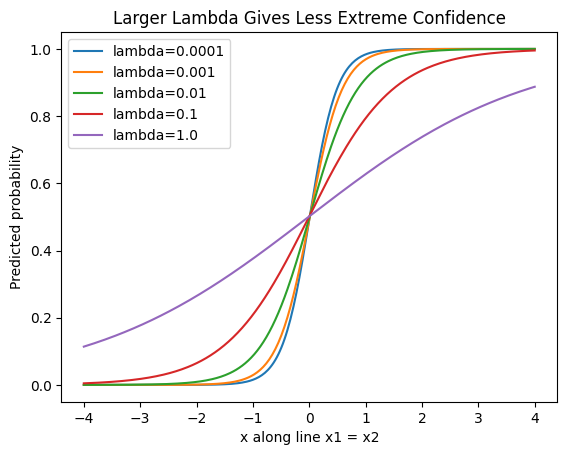

In [3152]:
x_line = np.linspace(-4, 4, 300)

# evaluate along x2 = x1
X_line_features = np.c_[x_line, x_line]
X_line = np.c_[np.ones(len(X_line_features)), X_line_features]

for w, lambda_value in zip(weights_by_lambda, lambda_values):
    mu_line = sigmoid(X_line @ w)
    plt.plot(x_line, mu_line, label=f"lambda={lambda_value}")

plt.xlabel("x along line x1 = x2")
plt.ylabel("Predicted probability")
plt.title("Larger Lambda Gives Less Extreme Confidence")
plt.legend()
plt.show()

**Note**:
- small lambda -> sharper sigmoid
- large lambda -> smoother sigmoid

## Standardization 

In [3153]:
np.random.seed(1)

n_per_class = 200

X0 = np.random.randn(n_per_class, 2) + np.array([-1, -1])
X1 = np.random.randn(n_per_class, 2) + np.array([1, 1])

X_features_unscaled = np.vstack([X0, X1])
y_scale = np.array([0] * n_per_class + [1] * n_per_class)

# make second feature huge
X_features_unscaled[:, 1] *= 1000

X_unscaled = np.c_[np.ones(len(X_features_unscaled)), X_features_unscaled]

Standardize only features not bias column

In [3154]:
feature_means = X_features_unscaled.mean(axis=0)
feature_stds = X_features_unscaled.std(axis=0)

X_features_scaled = (X_features_unscaled - feature_means) / feature_stds

X_scaled = np.c_[np.ones(len(X_features_scaled)), X_features_scaled]

Train both

In [3155]:
w_unscaled, loss_unscaled, norm_unscaled = logistic_gd_track_norm(
    X_unscaled,
    y_scale,
    learning_rate=0.000001,
    epochs=1000
)

w_scaled, loss_scaled, norm_scaled = logistic_gd_track_norm(
    X_scaled,
    y_scale,
    learning_rate=0.1,
    epochs=1000
)

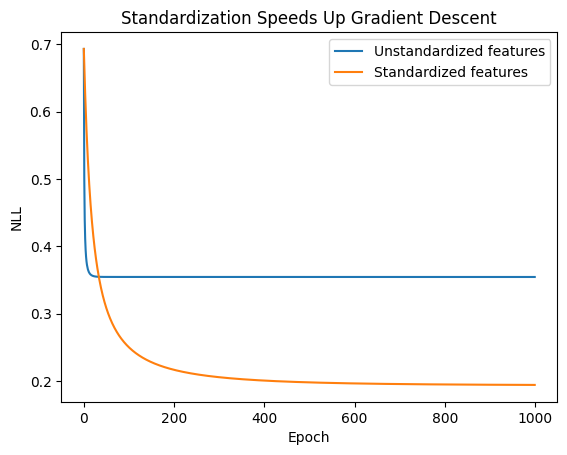

In [3156]:
plt.plot(loss_unscaled, label="Unstandardized features")
plt.plot(loss_scaled, label="Standardized features")

plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Standardization Speeds Up Gradient Descent")
plt.legend()
plt.show()

In [3157]:
print("Unstandardized final loss:", loss_unscaled[-1])
print("Standardized final loss:", loss_scaled[-1])

print("Unstandardized accuracy:", accuracy_score(X_unscaled, y_scale, w_unscaled))
print("Standardized accuracy:", accuracy_score(X_scaled, y_scale, w_scaled))

Unstandardized final loss: 0.35456035073973735
Standardized final loss: 0.1943122912789329
Unstandardized accuracy: 0.8525
Standardized accuracy: 0.9325


**Takeaway**:

- unstandardized features -> awkward scales, slow/unstable GD
- standardized features   -> comparable scales, faster convergence


# Logistic Regression Part 7: Nonlinear Boundaries via Feature Maps

## Goal

So far, logistic regression has used a linear decision boundary:

$$
w^\top x + b = 0
$$

For two features, this is a straight line:

$$
w_1x_1 + w_2x_2 + b = 0
$$

This works when the classes are linearly separable.

But some datasets cannot be separated by a straight line.

For example, suppose class `0` is an inner blob and class `1` is a surrounding ring. No straight line can separate the two classes well.

To fix this, we transform the features.

---

## Feature Maps

Instead of fitting logistic regression directly on `x`, we fit it on transformed features:

$$
\phi(x)
$$

The model becomes:

$$
\mu = \sigma(w^\top \phi(x))
$$

The model is still linear in the parameters `w`.

The nonlinearity comes from the fixed feature map `phi`.

---

## Circle Example

A circular decision boundary has the form:

$$
x_1^2 + x_2^2 = R^2
$$

We can get this boundary using the feature map:

$$
\phi(x_1, x_2) =
\begin{bmatrix}
1 \\
x_1^2 \\
x_2^2
\end{bmatrix}
$$

and weights:

$$
w =
\begin{bmatrix}
-R^2 \\
1 \\
1
\end{bmatrix}
$$

Then:

$$
w^\top \phi(x)
=
-R^2 + x_1^2 + x_2^2
$$

The decision boundary happens when:

$$
w^\top \phi(x) = 0
$$

so:

$$
x_1^2 + x_2^2 = R^2
$$

This is a circle.

---

## Important Idea

The model is still linear in the transformed features:

$$
w^\top \phi(x)
$$

but the boundary is nonlinear in the original input space.

So:

```text
linear in parameters
nonlinear in original features
```

This is why feature maps are powerful.

---

## Polynomial Features

We can make the model more flexible by adding polynomial features.

For degree `1`, we use:

$$
\phi(x) = [1, x_1, x_2]
$$

For degree `2`, we can use:

$$
\phi(x) = [1, x_1, x_2, x_1^2, x_1x_2, x_2^2]
$$

For higher degree `K`, we include all polynomial terms up to degree `K`.

As `K` increases, the model becomes more flexible.

But too much flexibility can cause overfitting.

---

## Role of Regularization

Higher-degree polynomial features can make the weights grow large and create overly wiggly decision boundaries.

To control this, we add L2 regularization:

$$
PNLL(w) = NLL(w) + \lambda \|w\|_2^2
$$

This penalizes large weights and makes the model less flexible.

So the tradeoff is:

```text
higher degree K       -> more flexible boundary
larger lambda         -> smoother, less flexible boundary
```

---

## Main Idea

Feature maps let logistic regression learn nonlinear boundaries while keeping the optimization problem similar.

Plain logistic regression:

$$
\mu = \sigma(w^\top x)
$$

Feature-map logistic regression:

$$
\mu = \sigma(w^\top \phi(x))
$$

The model is still logistic regression, but it is applied to transformed features.

In [3158]:
# helper functions

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def logistic_nll(X, y, w):
    logits = X @ w
    mu = sigmoid(logits)

    epsilon = 1e-15

    loss = -np.mean(
        y * np.log(mu + epsilon)
        + (1 - y) * np.log(1 - mu + epsilon)
    )

    return loss


def logistic_gradient_l2(X, y, w, lambda_value=0.0):
    n = len(y)
    mu = sigmoid(X @ w)

    gradient = (1 / n) * X.T @ (mu - y)

    # do not regularize the bias term
    gradient[1:] += 2 * lambda_value * w[1:]

    return gradient


def logistic_pnll_l2(X, y, w, lambda_value=0.0):
    nll = logistic_nll(X, y, w)

    # do not penalize bias
    penalty = lambda_value * np.sum(w[1:] ** 2)

    return nll + penalty


def logistic_gd_l2(X, y, lambda_value=0.0, learning_rate=0.1, epochs=5000):
    w = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        loss = logistic_pnll_l2(X, y, w, lambda_value)
        loss_history.append(loss)

        gradient = logistic_gradient_l2(X, y, w, lambda_value)

        w = w - learning_rate * gradient

    return w, loss_history


def accuracy_score(X, y, w):
    mu = sigmoid(X @ w)
    y_pred = (mu >= 0.5).astype(int)

    return np.mean(y_pred == y)

## Generate Circle/Ring Data

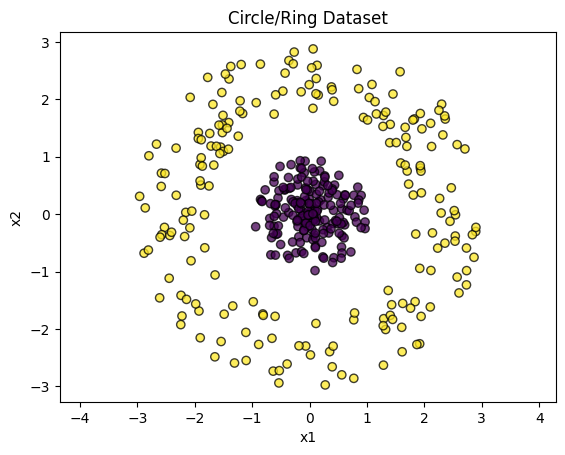

In [3159]:
np.random.seed(0)

n_inner = 200
n_outer = 200

# inner blob: class 0
r_inner = np.random.uniform(0.0, 1.0, n_inner)
theta_inner = np.random.uniform(0, 2 * np.pi, n_inner)

x1_inner = r_inner * np.cos(theta_inner)
x2_inner = r_inner * np.sin(theta_inner)

# outer ring: class 1
r_outer = np.random.uniform(1.8, 3.0, n_outer)
theta_outer = np.random.uniform(0, 2 * np.pi, n_outer)

x1_outer = r_outer * np.cos(theta_outer)
x2_outer = r_outer * np.sin(theta_outer)

X_inner = np.c_[x1_inner, x2_inner]
X_outer = np.c_[x1_outer, x2_outer]

X_features = np.vstack([X_inner, X_outer])
y = np.array([0] * n_inner + [1] * n_outer)

plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Circle/Ring Dataset")
plt.axis("equal")
plt.show()

## Fit plain regression line in raw features 

In [3160]:
X_raw = np.c_[np.ones(len(X_features)), X_features]

w_raw, loss_raw = logistic_gd_l2(
    X_raw,
    y,
    lambda_value=0.0,
    learning_rate=0.1,
    epochs=5000
)

print("Raw feature weights:", w_raw)
print("Raw feature accuracy:", accuracy_score(X_raw, y, w_raw))
print("Raw feature final loss:", loss_raw[-1])

Raw feature weights: [-0.01086916 -0.00694125  0.09892763]
Raw feature accuracy: 0.57
Raw feature final loss: 0.6913409019647632


**Note**: This model performs poorly


## Define circular feature map

In [3161]:
def circular_features(X_features):
    x1 = X_features[:, 0]
    x2 = X_features[:, 1]

    # phi(x) = [1, x1^2, x2^2]
    X_phi = np.c_[np.ones(len(X_features)), x1 ** 2, x2 ** 2]

    return X_phi

In [3162]:
X_circle = circular_features(X_features)

w_circle, loss_circle = logistic_gd_l2(
    X_circle,
    y,
    lambda_value=0.001,
    learning_rate=0.1,
    epochs=5000
)

print("Circular feature weights:", w_circle)
print("Circular feature accuracy:", accuracy_score(X_circle, y, w_circle))
print("Circular feature final loss:", loss_circle[-1])

Circular feature weights: [-5.63877966  2.56160741  2.41361192]
Circular feature accuracy: 1.0
Circular feature final loss: 0.02170053355469942


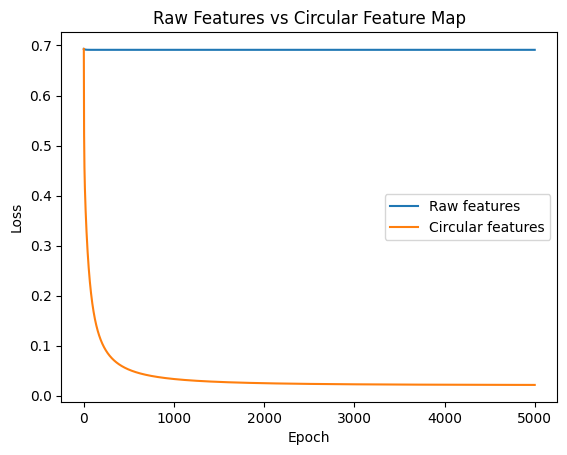

In [3163]:
plt.plot(loss_raw, label="Raw features")
plt.plot(loss_circle, label="Circular features")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Raw Features vs Circular Feature Map")
plt.legend()
plt.show()

In [3164]:
def plot_boundary(X_features, y, feature_map, w, title):
    x1_min, x1_max = X_features[:, 0].min() - 1, X_features[:, 0].max() + 1
    x2_min, x2_max = X_features[:, 1].min() - 1, X_features[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid_features = np.c_[xx1.ravel(), xx2.ravel()]
    grid_X = feature_map(grid_features)

    grid_mu = sigmoid(grid_X @ w)
    grid_mu = grid_mu.reshape(xx1.shape)

    plt.contourf(xx1, xx2, grid_mu, levels=30, alpha=0.6)
    plt.colorbar(label="Predicted probability")

    plt.contour(xx1, xx2, grid_mu, levels=[0.5], linewidths=2)

    plt.scatter(X_features[:, 0], X_features[:, 1], c=y, edgecolor="k", alpha=0.75)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.show()

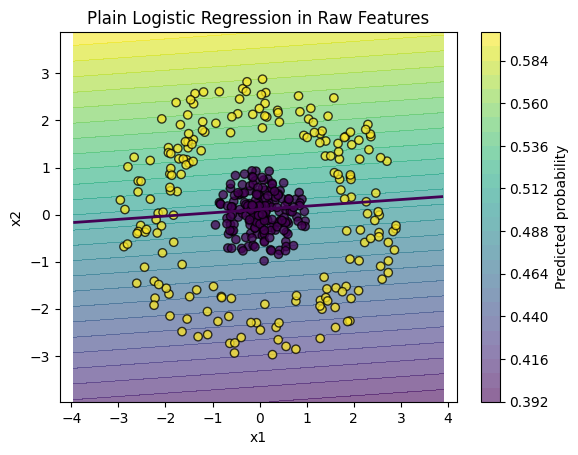

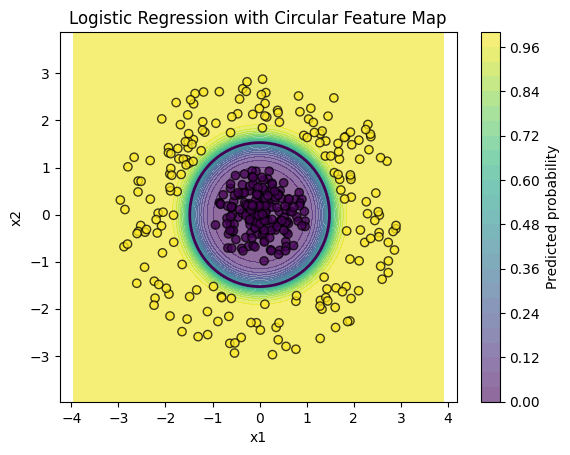

In [3165]:
def raw_features(X_features):
    return np.c_[np.ones(len(X_features)), X_features]


plot_boundary(
    X_features,
    y,
    raw_features,
    w_raw,
    "Plain Logistic Regression in Raw Features"
)

plot_boundary(
    X_features,
    y,
    circular_features,
    w_circle,
    "Logistic Regression with Circular Feature Map"
)

**Note**: You should see that the raw model tries to use a straight-line boundary, while the circular feature map recovers a circular boundary.

## Fully polynomial feature map

In [3166]:
def polynomial_features_2d(X_features, degree):
    x1 = X_features[:, 0]
    x2 = X_features[:, 1]

    features = [np.ones(len(X_features))]

    for total_degree in range(1, degree + 1):
        for power_x1 in range(total_degree + 1):
            power_x2 = total_degree - power_x1

            feature = (x1 ** power_x1) * (x2 ** power_x2)
            features.append(feature)

    return np.column_stack(features)

## Fit degree K = 1, 2, 4

In [3167]:
degrees = [1, 2, 4]

weights_by_degree = {}
loss_by_degree = {}
accuracy_by_degree = {}
norm_by_degree = {}

for degree in degrees:
    X_poly = polynomial_features_2d(X_features, degree=degree)

    w_poly, loss_poly = logistic_gd_l2(
        X_poly,
        y,
        lambda_value=0.0,
        learning_rate=0.05,
        epochs=5000
    )

    weights_by_degree[degree] = w_poly
    loss_by_degree[degree] = loss_poly
    accuracy_by_degree[degree] = accuracy_score(X_poly, y, w_poly)
    norm_by_degree[degree] = np.linalg.norm(w_poly[1:])

    print("Degree:", degree)
    print("Number of features:", X_poly.shape[1])
    print("Accuracy:", accuracy_by_degree[degree])
    print("Weight norm:", norm_by_degree[degree])
    print("Final loss:", loss_poly[-1])
    print()

Degree: 1
Number of features: 3
Accuracy: 0.57
Weight norm: 0.09917084733256502
Final loss: 0.6913409019647632

Degree: 2
Number of features: 6
Accuracy: 1.0
Weight norm: 3.531975481428662
Final loss: 0.010379182325249562

Degree: 4
Number of features: 15
Accuracy: 1.0
Weight norm: 1.8888297239126806
Final loss: 0.0049933895987860685



## Plot boundary for each degree

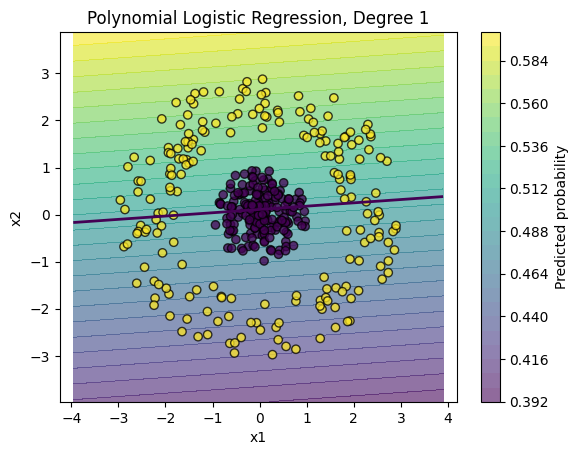

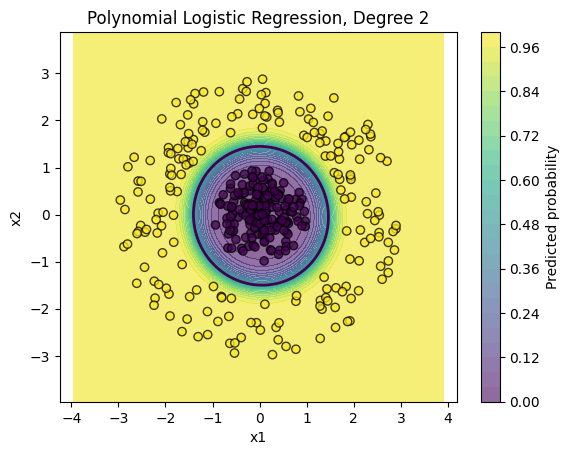

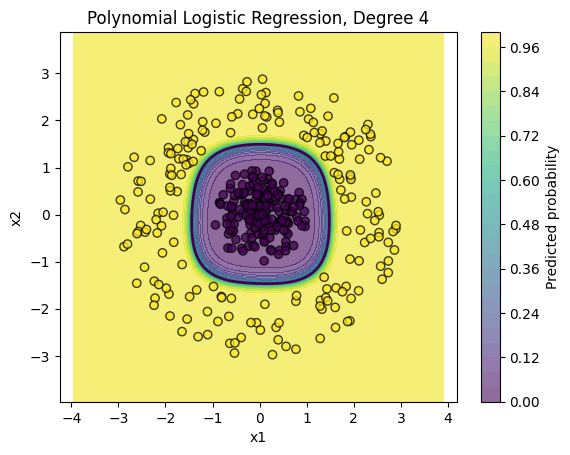

In [3168]:
for degree in degrees:
    feature_map = lambda Z, degree=degree: polynomial_features_2d(Z, degree)

    plot_boundary(
        X_features,
        y,
        feature_map,
        weights_by_degree[degree],
        f"Polynomial Logistic Regression, Degree {degree}"
    )

**Note**: 
- degree 1 -> underfits because boundary is linear
- degree 2 -> good circular-ish fit
- degree 4 -> more flexible; can overfit if data is noisy

## Adding more noise to show overfitting more clearly 

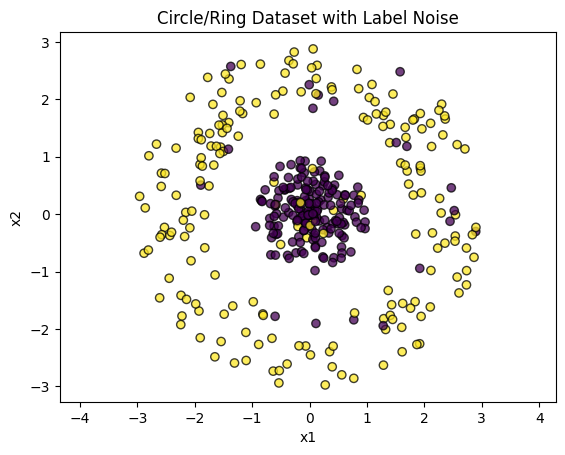

In [3169]:
np.random.seed(1)

y_noisy = y.copy()

flip_rate = 0.08
num_flips = int(flip_rate * len(y_noisy))

flip_indices = np.random.choice(len(y_noisy), size=num_flips, replace=False)
y_noisy[flip_indices] = 1 - y_noisy[flip_indices]

plt.scatter(X_features[:, 0], X_features[:, 1], c=y_noisy, edgecolor="k", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Circle/Ring Dataset with Label Noise")
plt.axis("equal")
plt.show()

flip degrees on noisy labels 

In [3170]:
weights_noisy_by_degree = {}

for degree in degrees:
    X_poly = polynomial_features_2d(X_features, degree=degree)

    w_poly, loss_poly = logistic_gd_l2(
        X_poly,
        y_noisy,
        lambda_value=0.0,
        learning_rate=0.03,
        epochs=8000
    )

    weights_noisy_by_degree[degree] = w_poly

    print("Degree:", degree)
    print("Accuracy:", accuracy_score(X_poly, y_noisy, w_poly))
    print("Weight norm:", np.linalg.norm(w_poly[1:]))
    print("Final loss:", loss_poly[-1])
    print()

Degree: 1
Accuracy: 0.67
Weight norm: 0.10562482358048855
Final loss: 0.6904295435701567

Degree: 2
Accuracy: 0.915
Weight norm: 1.4928447397589701
Final loss: 0.2804631820500508

Degree: 4
Accuracy: 0.92
Weight norm: 2.33914468498453
Final loss: 0.2533779497509998



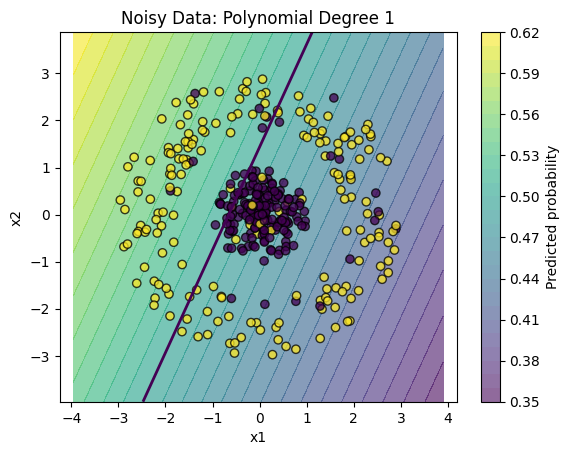

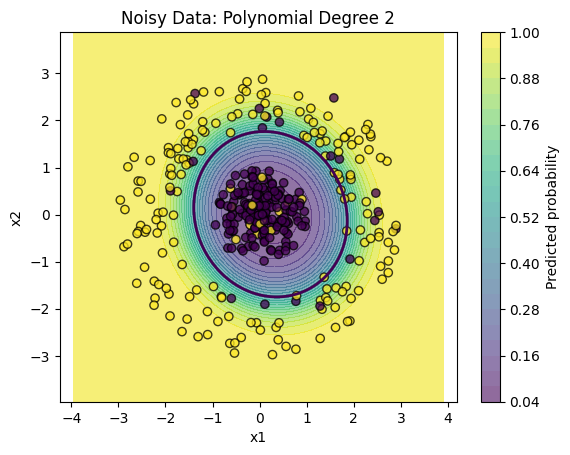

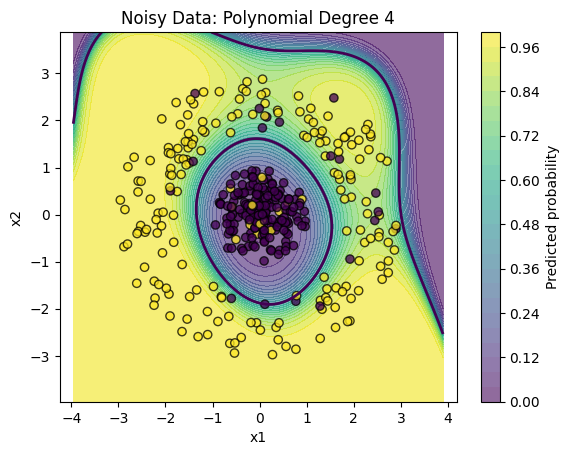

In [3171]:
for degree in degrees:
    feature_map = lambda Z, degree=degree: polynomial_features_2d(Z, degree)

    plot_boundary(
        X_features,
        y_noisy,
        feature_map,
        weights_noisy_by_degree[degree],
        f"Noisy Data: Polynomial Degree {degree}"
    )

## adding l2 regularization to degree 4

In [3172]:
X_poly_4 = polynomial_features_2d(X_features, degree=4)

w_degree4_no_reg, loss_degree4_no_reg = logistic_gd_l2(
    X_poly_4,
    y_noisy,
    lambda_value=0.0,
    learning_rate=0.03,
    epochs=8000
)

w_degree4_l2, loss_degree4_l2 = logistic_gd_l2(
    X_poly_4,
    y_noisy,
    lambda_value=0.01,
    learning_rate=0.03,
    epochs=8000
)

print("Degree 4 no regularization")
print("Accuracy:", accuracy_score(X_poly_4, y_noisy, w_degree4_no_reg))
print("Weight norm:", np.linalg.norm(w_degree4_no_reg[1:]))

print()

print("Degree 4 with L2")
print("Accuracy:", accuracy_score(X_poly_4, y_noisy, w_degree4_l2))
print("Weight norm:", np.linalg.norm(w_degree4_l2[1:]))

Degree 4 no regularization
Accuracy: 0.92
Weight norm: 2.33914468498453

Degree 4 with L2
Accuracy: 0.9225
Weight norm: 1.3082056446775168


## Plotting Comparison

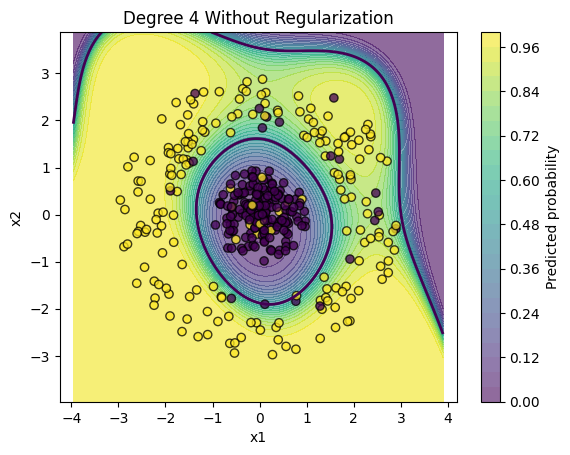

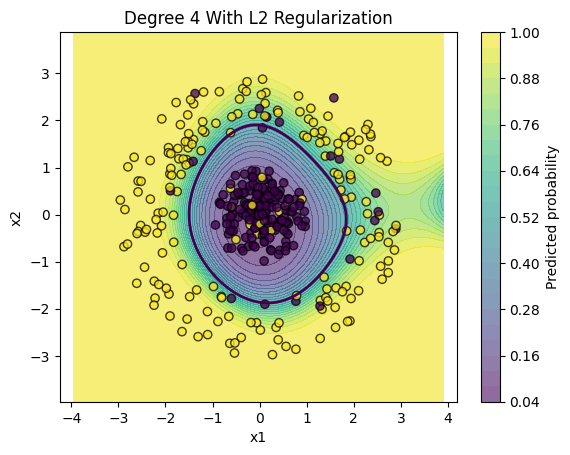

In [3173]:
plot_boundary(
    X_features,
    y_noisy,
    lambda Z: polynomial_features_2d(Z, degree=4),
    w_degree4_no_reg,
    "Degree 4 Without Regularization"
)

plot_boundary(
    X_features,
    y_noisy,
    lambda Z: polynomial_features_2d(Z, degree=4),
    w_degree4_l2,
    "Degree 4 With L2 Regularization"
)

Raw features:
- boundary is linear
- fails on circle/ring data

Circular features:
- boundary becomes circular
- model performs much better

Higher-degree polynomial features:
- degree 1 underfits
- degree 2 fits the circular structure
- degree 4 is more flexible and can overfit noisy labels

L2 regularization:
- shrinks weights
- smooths the decision boundary
- controls high-degree overfitting